# Brain Tumor MRI Classification

This notebook implements a complete pipeline for brain tumor classification:
1. Data download from Kaggle
2. Data exploration
3. Data preprocessing
4. Data augmentation
5. Model training (CNN, EfficientNet, MobileNet)
6. Model comparison
7. Model saving for deployment

Dataset: https://www.kaggle.com/datasets/masoudnickparvar/brain-tumor-mri-dataset

In [31]:
# Mount Google Drive to save models and results persistently
# from google.colab import drive
# drive.mount('/content/drive')

# Create project directory structure in Google Drive
import os

# Base directory in Google Drive
base_dir = './BrainTumorClassification'
os.makedirs(base_dir, exist_ok=True)

# Create subdirectories
data_dir = os.path.join(base_dir, 'data')
models_dir = os.path.join(base_dir, 'models')

for directory in [data_dir, models_dir]:
    os.makedirs(directory, exist_ok=True)

for subdir in ['raw', 'processed', 'augmented']:
    os.makedirs(os.path.join(data_dir, subdir), exist_ok=True)

for model_type in ['cnn_base', 'transfer_learning', 'mobilenet', 'comparison']:
    os.makedirs(os.path.join(models_dir, model_type), exist_ok=True)

In [32]:
# Install required packages
!pip install kaggle albumentations scikit-learn "tensorflow<2.11" seaborn "numpy<2.0"

## Dataset Download from Kaggle

You need to upload your kaggle.json file to use the Kaggle API.
If you don't have it:
1. Go to your Kaggle account
2. Click on 'Create New API Token'
3. It will download a file called kaggle.json
4. Upload this file when prompted below

In [33]:
import os
import platform
import shutil
import zipfile

# Define the expected data directory paths
train_dir = os.path.join(data_dir, 'raw', 'Training')
test_dir = os.path.join(data_dir, 'raw', 'Testing')

# Check if dataset already exists
if os.path.exists(train_dir) and os.path.exists(test_dir):
    print("Dataset already exists in the expected directories. Skipping download and extraction.")
else:
    # Check for Kaggle API setup
    if platform.system() == 'Windows':
        kaggle_json_path = os.path.join(os.environ['USERPROFILE'], '.kaggle', 'kaggle.json')
    else:
        # For Linux/Mac, standard path is ~/.kaggle/kaggle.json
        # Using ./kaggle.json is non-standard but can work if explicitly set up that way
        kaggle_json_path = os.path.expanduser('./kaggle.json')
        # Alternative standard path: kaggle_json_path = os.path.expanduser('~/.kaggle/kaggle.json')
    
    if not os.path.exists(kaggle_json_path):
        print(f"Kaggle API credentials not found at {kaggle_json_path}")
        print("Please download your kaggle.json from:")
        print("https://www.kaggle.com/settings - > API section -> Create New API Token")
        print(f"Then place it at: {kaggle_json_path}")
        print("Make sure the file permissions are restricted (e.g., chmod 600 on Linux/Mac)")
        raise FileNotFoundError(f"Kaggle credentials not found at {kaggle_json_path}")
    else:
        print("Kaggle API credentials found.")
        # Ensure correct permissions on Linux/Mac
        if platform.system() != 'Windows':
            os.chmod(kaggle_json_path, 0o600)
    
    # Import the kaggle package (you need to install it first with: pip install kaggle)
    try:
        import kaggle
    except ImportError:
        print("Kaggle package not found. Please install it with: pip install kaggle")
        raise
    
    # Check if the zip file already exists but hasn't been properly extracted
    dataset_zip_path = os.path.join(data_dir, 'raw', 'brain-tumor-mri-dataset.zip')
    raw_dataset_dir = os.path.join(data_dir, 'raw', 'Brain Tumor MRI Dataset')
    
    if not os.path.exists(dataset_zip_path):
        print("Downloading dataset from Kaggle...")
        # Use Kaggle Python API instead of shell command
        kaggle.api.dataset_download_files(
            'masoudnickparvar/brain-tumor-mri-dataset',
            path=os.path.join(data_dir, 'raw'),
            unzip=True
        )
        print("Dataset downloaded and unzipped.")
    else:
        print("ZIP file already exists, just need to extract if needed.")
    
    # Check if we need to extract the ZIP file manually (sometimes --unzip doesn't work)
    if os.path.exists(dataset_zip_path) and not os.path.exists(raw_dataset_dir):
        print("Extracting dataset manually...")
        with zipfile.ZipFile(dataset_zip_path, 'r') as zip_ref:
            zip_ref.extractall(os.path.join(data_dir, 'raw'))
        print("Dataset extracted.")
    
    # Move files to appropriate directories (if needed)
    if os.path.exists(raw_dataset_dir) and (not os.path.exists(train_dir) or not os.path.exists(test_dir)):
        print("Moving files to their final locations...")
        # This is to adapt to the dataset structure if it's nested differently
        if os.path.exists(os.path.join(raw_dataset_dir, 'Training')):
            # Create parent directory if it doesn't exist
            os.makedirs(os.path.dirname(train_dir), exist_ok=True)
            # Use shutil.copytree instead of cp shell command
            shutil.copytree(
                os.path.join(raw_dataset_dir, 'Training'),
                train_dir,
                dirs_exist_ok=True  # For Python 3.8+, otherwise use a check before copying
            )
        
        if os.path.exists(os.path.join(raw_dataset_dir, 'Testing')):
            # Create parent directory if it doesn't exist
            os.makedirs(os.path.dirname(test_dir), exist_ok=True)
            # Use shutil.copytree instead of cp shell command
            shutil.copytree(
                os.path.join(raw_dataset_dir, 'Testing'),
                test_dir,
                dirs_exist_ok=True  # For Python 3.8+, otherwise use a check before copying
            )
        
        print("Files moved successfully.")

print("Dataset ready for processing.")

Dataset already exists in the expected directories. Skipping download and extraction.
Dataset ready for processing.


In [34]:
import tensorflow as tf
import os
import platform
import sys
from pathlib import Path
import gc
from tensorflow.keras import mixed_precision
from tensorflow.keras.backend import clear_session
# Clear any problematic environment variables
os.environ.pop('TF_GPU_ALLOCATOR', None)  # Remove the async allocator
os.environ.pop('TF_XLA_FLAGS', None)      # Clear XLA flags
os.environ.pop('XLA_FLAGS', None)         # Clear any XLA flags

# Diagnostic information
print(f"Python: {sys.version}")
print(f"TensorFlow: {tf.__version__}")
print(f"Platform: {platform.system()} {platform.release()}")

os.environ['TF_XLA_FLAGS'] = '--tf_xla_enable_xla_devices=false'


# Simple GPU detection and configuration
print("Checking for GPU availability...")
gpus = tf.config.list_physical_devices('GPU')
if gpus:
    try:
        # Simplify configuration - just use memory growth
        for gpu in gpus:
            tf.config.experimental.set_memory_growth(gpu, True)
        print(f"GPU is available: {gpus}")
    except RuntimeError as e:
        print(f"Error configuring GPU: {e}")
        print("Attempting to use CPU instead...")
        tf.config.set_visible_devices([], 'GPU')
else:
    print("No GPU found. Using CPU.")
    
# Set the policy for mixed precision
policy = mixed_precision.Policy('mixed_float16')
mixed_precision.set_global_policy(policy)

print('Mixed precision policy set to:', mixed_precision.global_policy())

Python: 3.10.16 | packaged by Anaconda, Inc. | (main, Dec 11 2024, 16:19:12) [MSC v.1929 64 bit (AMD64)]
TensorFlow: 2.10.1
Platform: Windows 10
Checking for GPU availability...
GPU is available: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]
Mixed precision policy set to: <Policy "mixed_float16">


In [35]:
# Add checkpointing functionality
import json
import time

def save_checkpoint(phase_name):
    """Save a checkpoint after completing a major phase"""
    checkpoint_path = os.path.join(base_dir, f'checkpoint_{phase_name}.json')
    with open(checkpoint_path, 'w') as f:
        json.dump({
            'completed': True,
            'timestamp': time.time()
        }, f)
    print(f"Checkpoint saved for phase: {phase_name}")

def is_completed(phase_name):
    """Check if a phase was already completed"""
    checkpoint_path = os.path.join(base_dir, f'checkpoint_{phase_name}.json')
    return os.path.exists(checkpoint_path)

## 1. Data Exploration
Exploring the dataset structure, class distribution, and image characteristics

In [36]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image

# Define paths to data directories
train_dir = os.path.join(data_dir, 'raw', 'Training')
test_dir = os.path.join(data_dir, 'raw', 'Testing')

# List the classes (subfolders)
classes = sorted([d for d in os.listdir(train_dir) if os.path.isdir(os.path.join(train_dir, d))])
print(f"Detected classes: {classes}")

# Count images per class
train_counts = {}
test_counts = {}

for class_name in classes:
    train_class_dir = os.path.join(train_dir, class_name)
    test_class_dir = os.path.join(test_dir, class_name)

    train_files = [f for f in os.listdir(train_class_dir) if f.endswith(('.jpg', '.jpeg', '.png'))]
    test_files = [f for f in os.listdir(test_class_dir) if f.endswith(('.jpg', '.jpeg', '.png'))]

    train_counts[class_name] = len(train_files)
    test_counts[class_name] = len(test_files)

# Display dataset statistics
print("\nDataset Statistics:")
print(f"{'Class':<15} {'Training':<10} {'Testing':<10} {'Total':<10}")
print("-" * 45)

total_train = 0
total_test = 0
for class_name in classes:
    total = train_counts[class_name] + test_counts[class_name]
    total_train += train_counts[class_name]
    total_test += test_counts[class_name]
    print(f"{class_name:<15} {train_counts[class_name]:<10} {test_counts[class_name]:<10} {total:<10}")

print("-" * 45)
print(f"{'Total':<15} {total_train:<10} {total_test:<10} {total_train + total_test:<10}")

Detected classes: ['glioma', 'meningioma', 'notumor', 'pituitary']

Dataset Statistics:
Class           Training   Testing    Total     
---------------------------------------------
glioma          1321       300        1621      
meningioma      1339       306        1645      
notumor         1595       405        2000      
pituitary       1457       300        1757      
---------------------------------------------
Total           5712       1311       7023      


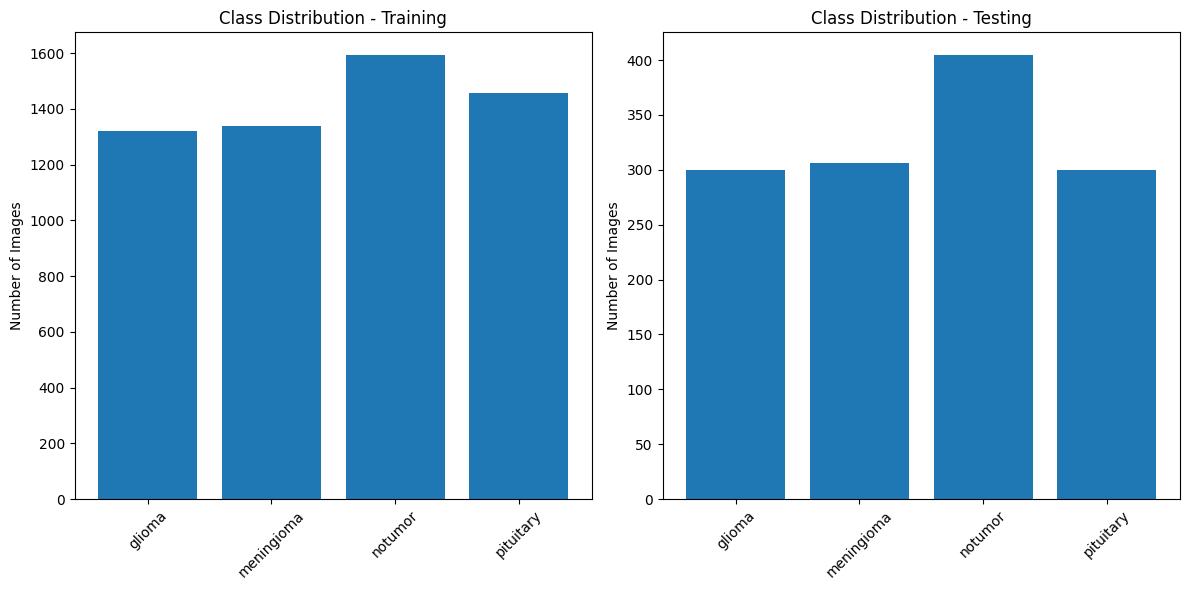

In [37]:
# Visualize class distribution
plt.figure(figsize=(12, 6))

plt.subplot(1, 2, 1)
plt.bar(train_counts.keys(), train_counts.values())
plt.title('Class Distribution - Training')
plt.xticks(rotation=45)
plt.ylabel('Number of Images')

plt.subplot(1, 2, 2)
plt.bar(test_counts.keys(), test_counts.values())
plt.title('Class Distribution - Testing')
plt.xticks(rotation=45)
plt.ylabel('Number of Images')

plt.tight_layout()
plt.show()

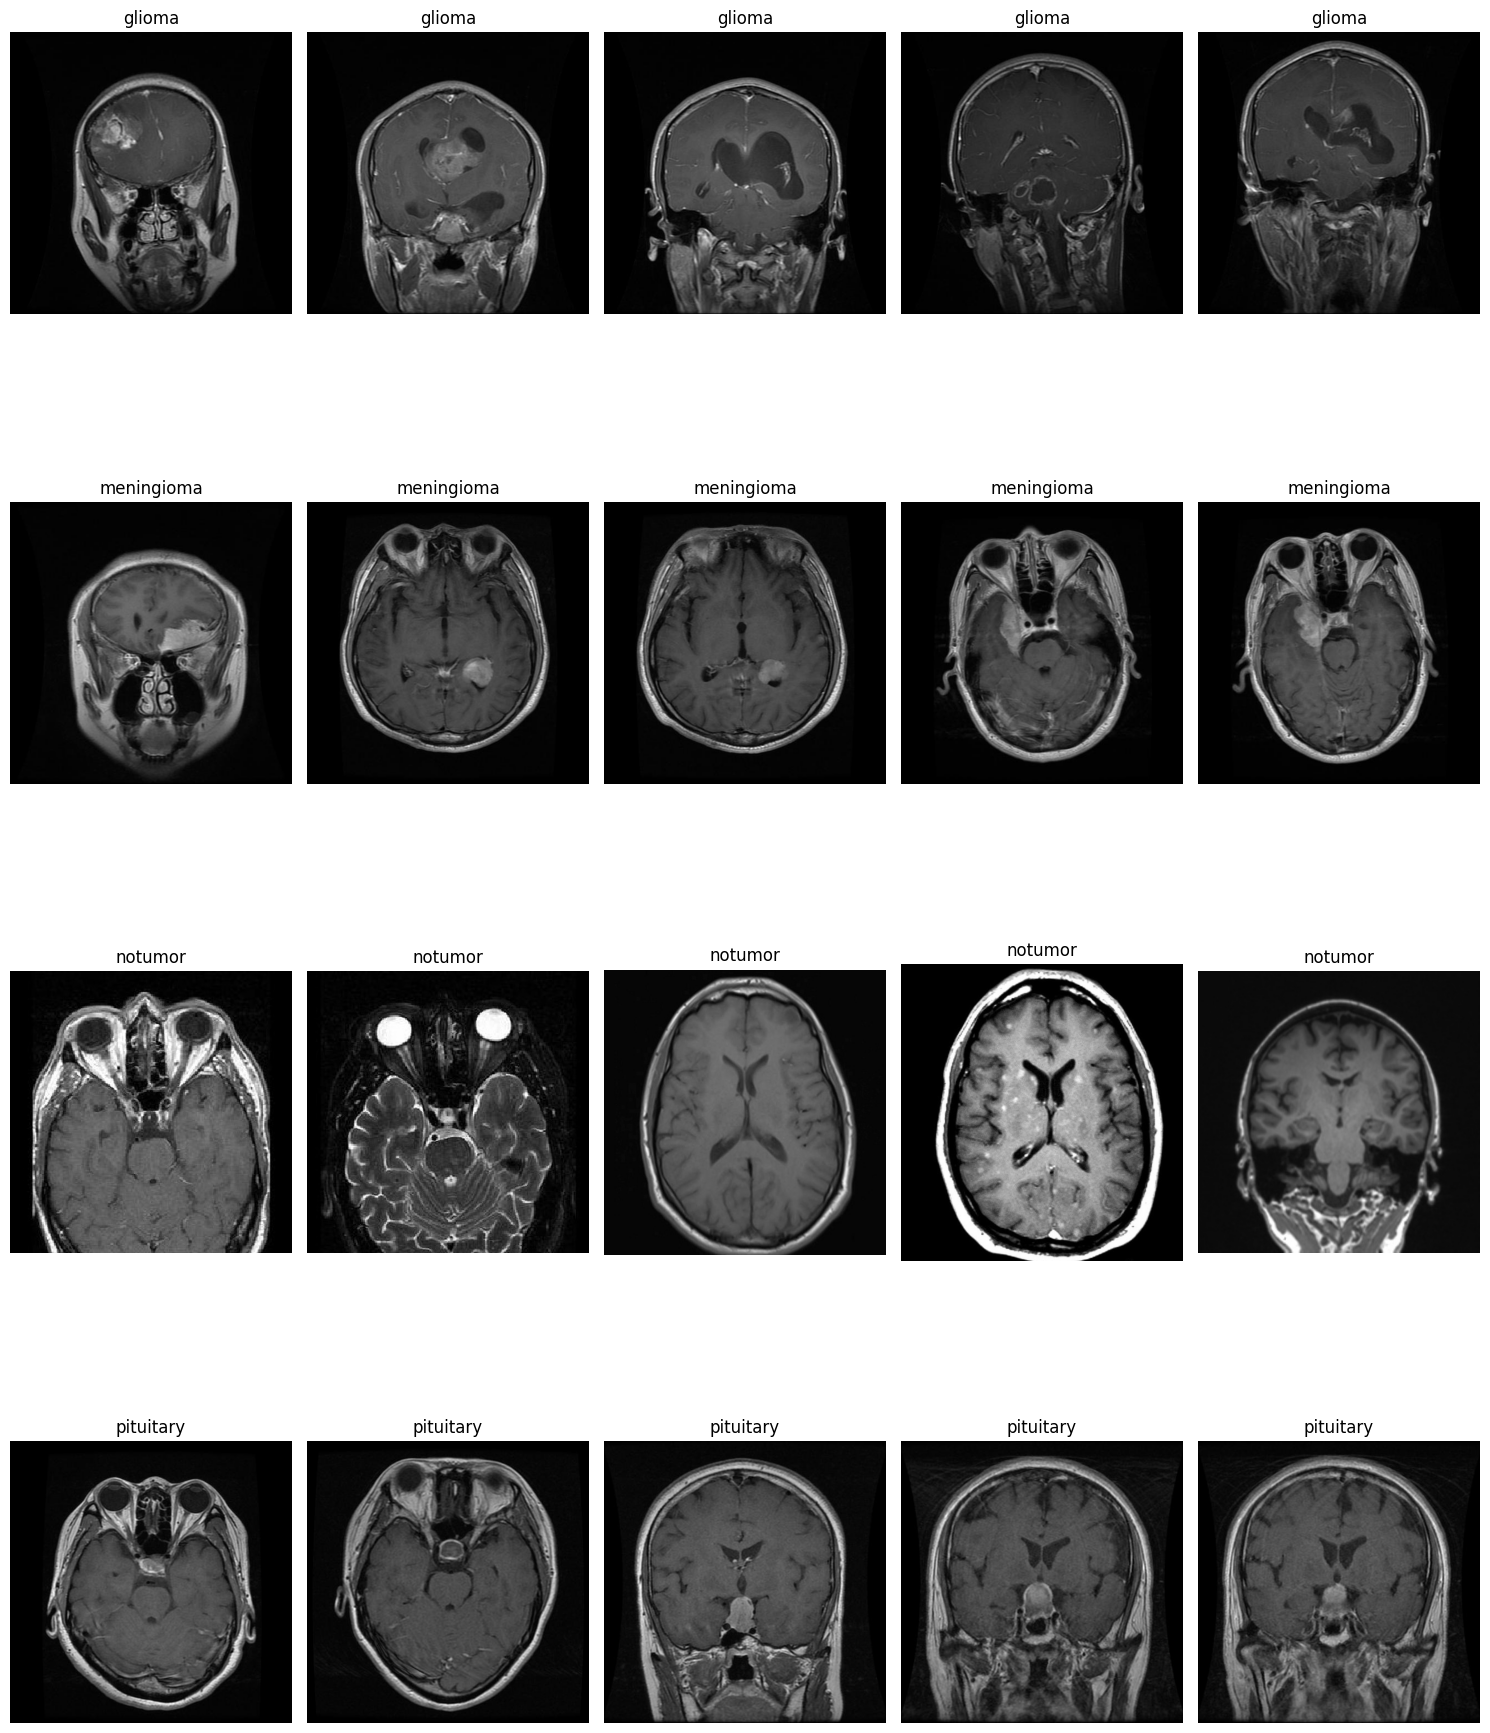

In [38]:
# Visualize sample images from each class
plt.figure(figsize=(15, 5*len(classes)))

for i, class_name in enumerate(classes):
    train_class_dir = os.path.join(train_dir, class_name)
    image_files = [f for f in os.listdir(train_class_dir) if f.endswith(('.jpg', '.jpeg', '.png'))][:5]  # 5 images per class

    for j, img_file in enumerate(image_files):
        img_path = os.path.join(train_class_dir, img_file)
        img = Image.open(img_path)

        plt.subplot(len(classes), 5, i*5 + j + 1)
        plt.imshow(img)
        plt.title(f"{class_name}")
        plt.axis('off')

plt.tight_layout()
plt.show()

In [39]:
# Check image dimensions
sample_images = []
for class_name in classes:
    train_class_dir = os.path.join(train_dir, class_name)
    image_files = [f for f in os.listdir(train_class_dir) if f.endswith(('.jpg', '.jpeg', '.png'))][:5]

    for img_file in image_files:
        img_path = os.path.join(train_class_dir, img_file)
        img = Image.open(img_path)
        sample_images.append((img.width, img.height))

widths, heights = zip(*sample_images)
print(f"Minimum image dimensions: {min(widths)}x{min(heights)}")
print(f"Maximum image dimensions: {max(widths)}x{max(heights)}")
print(f"Average image dimensions: {sum(widths)/len(widths):.1f}x{sum(heights)/len(heights):.1f}")

Minimum image dimensions: 350x350
Maximum image dimensions: 605x613
Average image dimensions: 499.4x501.4


## 2. Data Preprocessing
Resize, normalize, and split the dataset for training, validation, and testing

In [40]:
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
from tensorflow.keras.utils import to_categorical
from sklearn.model_selection import train_test_split

# Parameters
img_size = (128, 128)  # Target image size

processed_dir = os.path.join(data_dir, 'processed')
os.makedirs(processed_dir, exist_ok=True)

# Map classes to indices
class_to_idx = {cls: idx for idx, cls in enumerate(classes)}
print(f"Classes: {classes}")

def clear_memory():
    """Clear memory between processing stages"""
    gc.collect()
    clear_session()
    print("Memory cleared")

def load_dataset(data_dir, img_size, batch_size=64):
    """Load and preprocess images from a directory in batches to save memory"""
    X = []
    y = []

    # Iterate through classes
    for class_name in os.listdir(data_dir):
        class_dir = os.path.join(data_dir, class_name)
        if not os.path.isdir(class_dir):
            continue

        class_idx = class_to_idx[class_name]
        img_files = [f for f in os.listdir(class_dir) if f.endswith(('.jpg', '.jpeg', '.png'))]
        
        # Process in batches
        for i in range(0, len(img_files), batch_size):
            batch_files = img_files[i:i+batch_size]
            batch_X = []
            batch_y = []
            
            for img_file in batch_files:
                img_path = os.path.join(class_dir, img_file)
                try:
                    # Load and preprocess image
                    img = Image.open(img_path).convert('RGB')
                    img = img.resize(img_size)
                    img_array = np.array(img) / 255.0  # Normalization

                    batch_X.append(img_array)
                    batch_y.append(class_idx)
                except Exception as e:
                    print(f"Error with image {img_path}: {e}")
            
            # Add batch to main arrays
            X.extend(batch_X)
            y.extend(batch_y)
            
            # Free memory after each batch
            batch_X = None
            batch_y = None
            gc.collect()
            
            print(f"Processed {i+len(batch_files)}/{len(img_files)} images for class {class_name}")

    return np.array(X), np.array(y)
# Load training and test sets
print("Loading training set...")
X_train, y_train = load_dataset(train_dir, img_size)
clear_memory()
print("Loading test set...")
X_test, y_test = load_dataset(test_dir, img_size)
clear_memory()

Classes: ['glioma', 'meningioma', 'notumor', 'pituitary']
Loading training set...
Processed 64/1321 images for class glioma
Processed 64/1321 images for class glioma
Processed 128/1321 images for class glioma
Processed 192/1321 images for class glioma
Processed 256/1321 images for class glioma
Processed 320/1321 images for class glioma
Processed 384/1321 images for class glioma
Processed 448/1321 images for class glioma
Processed 512/1321 images for class glioma
Processed 576/1321 images for class glioma
Processed 640/1321 images for class glioma
Processed 704/1321 images for class glioma
Processed 768/1321 images for class glioma
Processed 832/1321 images for class glioma
Processed 896/1321 images for class glioma
Processed 960/1321 images for class glioma
Processed 1024/1321 images for class glioma
Processed 1088/1321 images for class glioma
Processed 1152/1321 images for class glioma
Processed 1216/1321 images for class glioma
Processed 1280/1321 images for class glioma
Processed 13

In [41]:
# Split training set to create a validation set
X_train, X_val, y_train, y_val = train_test_split(
    X_train, y_train, test_size=0.2, random_state=42, stratify=y_train
)

# Convert labels to one-hot encoding
num_classes = len(classes)
y_train = to_categorical(y_train, num_classes)
y_val = to_categorical(y_val, num_classes)
y_test = to_categorical(y_test, num_classes)

print(f"Training set: {X_train.shape}, {y_train.shape}")
print(f"Validation set: {X_val.shape}, {y_val.shape}")
print(f"Test set: {X_test.shape}, {y_test.shape}")

Training set: (4569, 128, 128, 3), (4569, 4)
Validation set: (1143, 128, 128, 3), (1143, 4)
Test set: (1311, 128, 128, 3), (1311, 4)


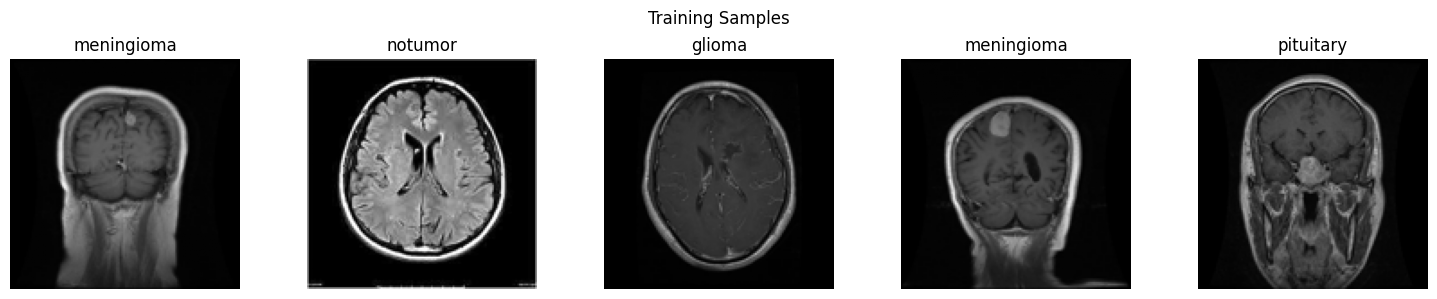

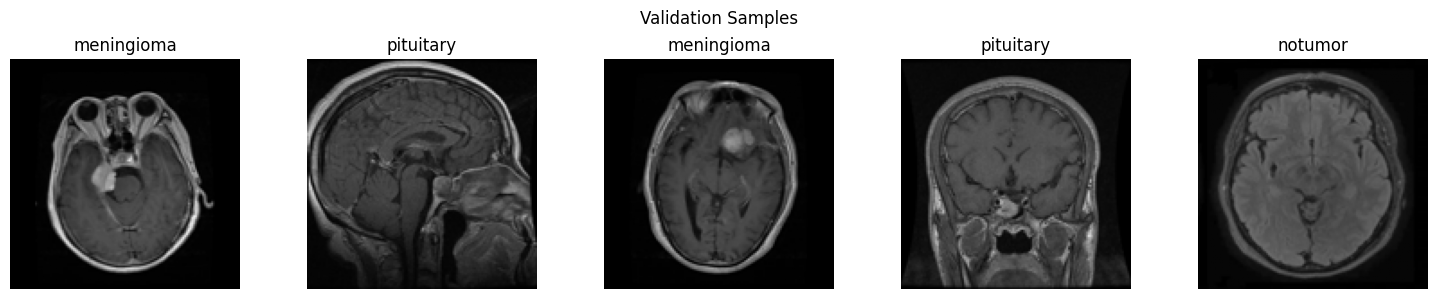

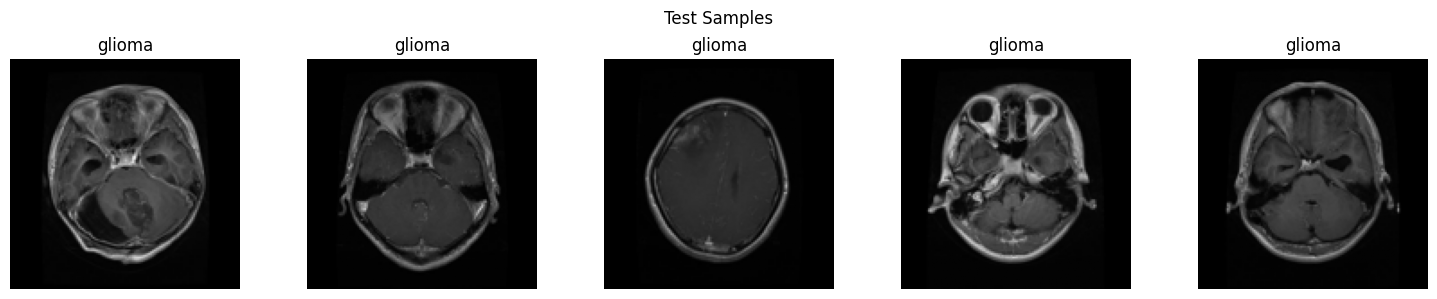

In [42]:
# Visualize samples from each set
def visualize_samples(X, y, title, num_samples=5):
    """Visualize samples from the dataset"""
    y_idx = np.argmax(y, axis=1) if len(y.shape) > 1 else y

    plt.figure(figsize=(15, 3))
    plt.suptitle(title)

    for i in range(min(num_samples, len(X))):
        plt.subplot(1, num_samples, i+1)
        plt.imshow(X[i])
        plt.title(f"{classes[y_idx[i]]}")
        plt.axis('off')

    plt.tight_layout()
    plt.show()

visualize_samples(X_train, y_train, "Training Samples")
visualize_samples(X_val, y_val, "Validation Samples")
visualize_samples(X_test, y_test, "Test Samples")

In [43]:
# Save preprocessed data
np.save(os.path.join(processed_dir, 'X_train.npy'), X_train)
np.save(os.path.join(processed_dir, 'X_val.npy'), X_val)
np.save(os.path.join(processed_dir, 'X_test.npy'), X_test)
np.save(os.path.join(processed_dir, 'y_train.npy'), y_train)
np.save(os.path.join(processed_dir, 'y_val.npy'), y_val)
np.save(os.path.join(processed_dir, 'y_test.npy'), y_test)

# Save class names
with open(os.path.join(processed_dir, 'classes.txt'), 'w') as f:
    f.write('\n'.join(classes))

print(f"Preprocessed data saved to {processed_dir}")

Preprocessed data saved to ./BrainTumorClassification\data\processed


## 3. Data Augmentation
Increase dataset size and variety through augmentation

In [44]:
import numpy as np
import matplotlib.pyplot as plt
import albumentations as A
from tensorflow.keras.preprocessing.image import ImageDataGenerator

# Create the augmented directory
augmented_dir = os.path.join(data_dir, 'augmented')
os.makedirs(augmented_dir, exist_ok=True)

# Load preprocessed data
X_train = np.load(os.path.join(processed_dir, 'X_train.npy'))
y_train = np.load(os.path.join(processed_dir, 'y_train.npy'))

with open(os.path.join(processed_dir, 'classes.txt'), 'r') as f:
    classes = [line.strip() for line in f.readlines()]

print(f"Loaded data: X_train.shape={X_train.shape}, y_train.shape={y_train.shape}")
print(f"Classes: {classes}")

Loaded data: X_train.shape=(4569, 128, 128, 3), y_train.shape=(4569, 4)
Classes: ['glioma', 'meningioma', 'notumor', 'pituitary']


Examples of augmentation with Keras ImageDataGenerator:


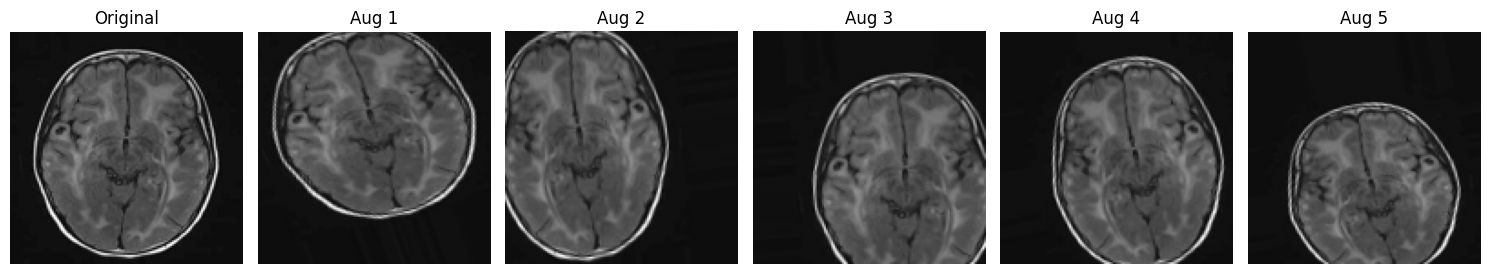

In [45]:
# Visualize Keras ImageDataGenerator augmentation
def visualize_keras_augmentation(X_sample, datagen, n_samples=5):
    # Choose a random image
    idx = np.random.randint(0, len(X_sample))
    img = X_sample[idx].reshape((1,) + X_sample[idx].shape)

    plt.figure(figsize=(15, 3))

    # Original image
    plt.subplot(1, n_samples+1, 1)
    plt.imshow(X_sample[idx])
    plt.title("Original")
    plt.axis('off')

    # Augmented images
    i = 0
    for batch in datagen.flow(img, batch_size=1):
        i += 1
        plt.subplot(1, n_samples+1, i+1)
        plt.imshow(batch[0])
        plt.title(f"Aug {i}")
        plt.axis('off')

        if i >= n_samples:
            break

    plt.tight_layout()
    plt.show()

# Create a Keras generator
keras_datagen = ImageDataGenerator(
    rotation_range=20,
    width_shift_range=0.2,
    height_shift_range=0.2,
    shear_range=0.2,
    zoom_range=0.2,
    horizontal_flip=True,
    fill_mode='nearest'
)

print("Examples of augmentation with Keras ImageDataGenerator:")
visualize_keras_augmentation(X_train, keras_datagen)

Examples of augmentation with Albumentations:


c:\Users\raedb\.conda\envs\colab-gpu\lib\site-packages\albumentations\core\validation.py:111: UserWarning: ShiftScaleRotate is a special case of Affine transform. Please use Affine transform instead.
  original_init(self, **validated_kwargs)


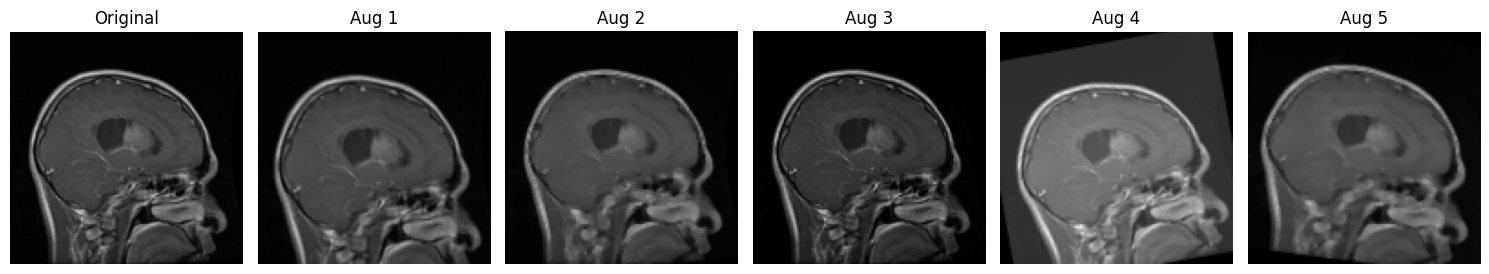

In [46]:
# Use Albumentations for more flexible and faster augmentation
def apply_albumentations(image, augmentation):
    # Albumentations expects image with values 0-255
    img_255 = (image * 255).astype(np.uint8)

    # Apply transformations
    augmented = augmentation(image=img_255)

    # Renormalize to 0-1
    return augmented['image'].astype(np.float32) / 255.0

def visualize_albumentations(X_sample, augmentation, n_samples=5):
    # Choose a random image
    idx = np.random.randint(0, len(X_sample))
    img = X_sample[idx]

    plt.figure(figsize=(15, 3))

    # Original image
    plt.subplot(1, n_samples+1, 1)
    plt.imshow(img)
    plt.title("Original")
    plt.axis('off')

    # Augmented images
    for i in range(n_samples):
        aug_img = apply_albumentations(img, augmentation)
        plt.subplot(1, n_samples+1, i+2)
        plt.imshow(aug_img)
        plt.title(f"Aug {i+1}")
        plt.axis('off')

    plt.tight_layout()
    plt.show()

# Create an augmentation pipeline with Albumentations
augmentation = A.Compose([
    A.OneOf([
        A.RandomBrightnessContrast(brightness_limit=0.2, contrast_limit=0.2, p=0.8),
        A.RandomGamma(gamma_limit=(80, 120), p=0.8),
    ], p=0.5),
    A.OneOf([
        A.ElasticTransform(alpha=1, sigma=50, p=0.5),
        A.GridDistortion(num_steps=5, distort_limit=0.3, p=0.5),
        A.OpticalDistortion(distort_limit=0.3, p=0.5),
    ], p=0.3),
    A.ShiftScaleRotate(shift_limit=0.0625, scale_limit=0.1, rotate_limit=20, p=0.5),
    A.OneOf([
        A.Blur(blur_limit=3, p=0.5),
        A.MedianBlur(blur_limit=3, p=0.5),
        A.GaussianBlur(blur_limit=3, p=0.5),
    ], p=0.2),
    A.HorizontalFlip(p=0.5),
    A.RandomRotate90(p=0.2),
])

print("Examples of augmentation with Albumentations:")
visualize_albumentations(X_train, augmentation)

In [47]:
# Skip augmentation if already done
if is_completed('augmentation') and os.path.exists(os.path.join(augmented_dir, 'X_train_aug.npy')):
    print("Loading pre-augmented dataset...")
    try:
        # Check if files are valid
        X_sample = np.load(os.path.join(augmented_dir, 'X_train_aug.npy'), mmap_mode='r')[:5]
        print(f"Found augmented data. Loading full dataset...")
        
        # Actually load the full augmented dataset
        X_train_aug = np.load(os.path.join(augmented_dir, 'X_train_aug.npy'))
        y_train_aug = np.load(os.path.join(augmented_dir, 'y_train_aug.npy'))
        
        print(f"Loaded augmented data: {X_train_aug.shape}")
        is_aug_completed = True
    except Exception as e:
        print(f"Error loading augmented data: {e}")
        print("Will re-generate augmented dataset.")
        is_aug_completed = False
else:
    is_aug_completed = False

if not is_aug_completed:
    # More memory-efficient augmentation
    def generate_augmented_dataset_in_batches(X_train, y_train, n_augmentations=3, batch_size=100):
        """Generate augmented dataset in batches to avoid memory issues"""
        # First, count total expected size
        total_size = len(X_train) + len(X_train) * n_augmentations
        print(f"Will generate approximately {total_size} samples")
        
        # Pre-allocate arrays for better memory efficiency
        X_train_aug = np.zeros((total_size, *X_train.shape[1:]), dtype=X_train.dtype)
        y_train_aug = np.zeros((total_size, *y_train.shape[1:]), dtype=y_train.dtype)
        
        # Copy original data
        X_train_aug[:len(X_train)] = X_train
        y_train_aug[:len(y_train)] = y_train
        
        # Track current position in the arrays
        current_idx = len(X_train)
        
        # For each class
        for class_idx in range(y_train.shape[1]):
            # Find indices of examples in this class
            indices = np.where(y_train[:,class_idx] == 1)[0]
            print(f"Class {class_idx}: {len(indices)} examples")
            
            # Process in batches
            for start_idx in range(0, len(indices), batch_size):
                end_idx = min(start_idx + batch_size, len(indices))
                batch_indices = indices[start_idx:end_idx]
                
                for idx in batch_indices:
                    img = X_train[idx]
                    label = y_train[idx]
                    
                    # Generate augmented versions
                    for _ in range(n_augmentations):
                        if current_idx < total_size:
                            aug_img = apply_albumentations(img, augmentation)
                            X_train_aug[current_idx] = aug_img
                            y_train_aug[current_idx] = label
                            current_idx += 1
                
                # Free memory
                gc.collect()
                print(f"Processed {end_idx}/{len(indices)} images for class {class_idx}")
        
        # Trim arrays to actual size used
        X_train_aug = X_train_aug[:current_idx]
        y_train_aug = y_train_aug[:current_idx]
        
        # Shuffle the data
        indices = np.arange(len(X_train_aug))
        np.random.shuffle(indices)
        X_train_aug = X_train_aug[indices]
        y_train_aug = y_train_aug[indices]
        
        return X_train_aug, y_train_aug

    print("Generating augmented dataset...")
    X_train_aug, y_train_aug = generate_augmented_dataset_in_batches(X_train, y_train, n_augmentations=3, batch_size=50)
    print(f"Original data: {X_train.shape}, Augmented data: {X_train_aug.shape}")
    
    # Save augmented data
    np.save(os.path.join(augmented_dir, 'X_train_aug.npy'), X_train_aug)
    np.save(os.path.join(augmented_dir, 'y_train_aug.npy'), y_train_aug)
    
    # Also copy validation and test data
    np.save(os.path.join(augmented_dir, 'X_val.npy'), np.load(os.path.join(processed_dir, 'X_val.npy')))
    np.save(os.path.join(augmented_dir, 'X_test.npy'), np.load(os.path.join(processed_dir, 'X_test.npy')))
    np.save(os.path.join(augmented_dir, 'y_val.npy'), np.load(os.path.join(processed_dir, 'y_val.npy')))
    np.save(os.path.join(augmented_dir, 'y_test.npy'), np.load(os.path.join(processed_dir, 'y_test.npy')))
    
    with open(os.path.join(augmented_dir, 'classes.txt'), 'w') as f:
        f.write('\n'.join(classes))
    
    # Mark completion
    save_checkpoint('augmentation')
    
    print(f"Augmented data saved to {augmented_dir}")

Loading pre-augmented dataset...
Found augmented data. Loading full dataset...
Loaded augmented data: (18276, 128, 128, 3)


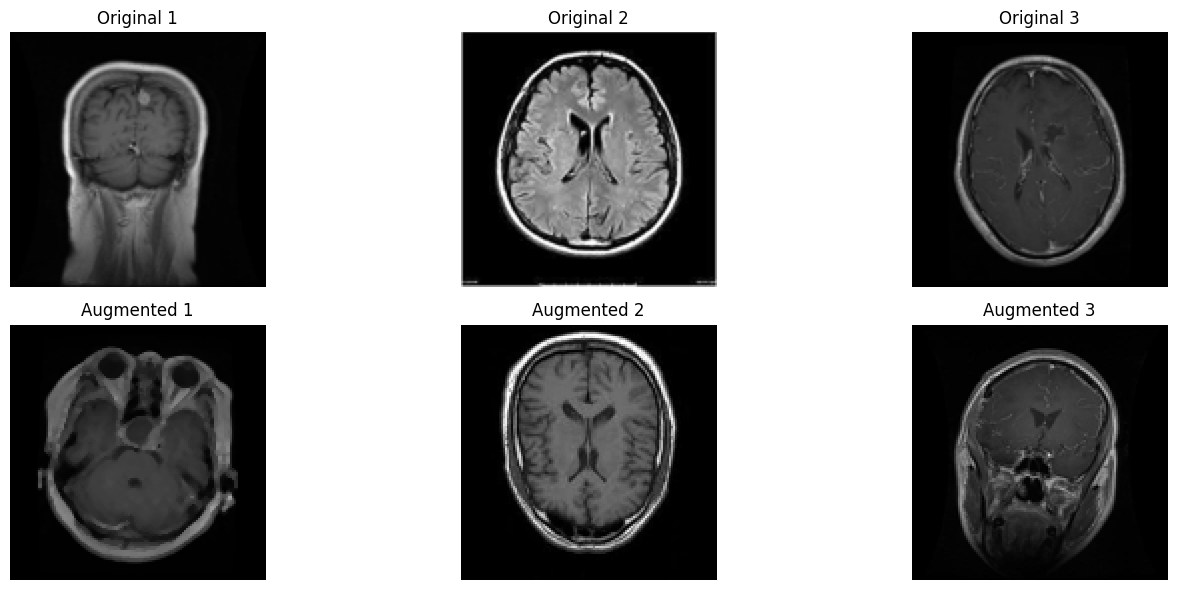

In [48]:
# Visualize some examples before and after augmentation
def visualize_comparison(X_orig, X_aug, n_samples=3):
    plt.figure(figsize=(15, 6))

    for i in range(n_samples):
        # Original image
        plt.subplot(2, n_samples, i+1)
        plt.imshow(X_orig[i])
        plt.title(f"Original {i+1}")
        plt.axis('off')

        # Augmented image (choose a different example from the augmented set)
        aug_idx = len(X_orig) + i  # Take an example that's not in the original set
        plt.subplot(2, n_samples, n_samples+i+1)
        plt.imshow(X_aug[aug_idx])
        plt.title(f"Augmented {i+1}")
        plt.axis('off')

    plt.tight_layout()
    plt.show()

visualize_comparison(X_train, X_train_aug)

## 4. CNN Base Model
Train a basic CNN model for brain tumor classification

In [49]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout, BatchNormalization
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping, ReduceLROnPlateau
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score

# Parameters
cnn_model_dir = os.path.join(models_dir, 'cnn_base')
os.makedirs(cnn_model_dir, exist_ok=True)
model_name = 'brain_tumor_cnn_base'
input_shape = (128, 128, 3)
num_classes = 4
batch_size = 32
epochs = 20

# Load the data
X_train = np.load(os.path.join(augmented_dir, 'X_train_aug.npy'))
X_val = np.load(os.path.join(augmented_dir, 'X_val.npy'))
X_test = np.load(os.path.join(augmented_dir, 'X_test.npy'))
y_train = np.load(os.path.join(augmented_dir, 'y_train_aug.npy'))
y_val = np.load(os.path.join(augmented_dir, 'y_val.npy'))
y_test = np.load(os.path.join(augmented_dir, 'y_test.npy'))

with open(os.path.join(augmented_dir, 'classes.txt'), 'r') as f:
    classes = [line.strip() for line in f.readlines()]

print(f"Data loaded - X_train: {X_train.shape}, y_train: {y_train.shape}")
print(f"Classes: {classes}")

Data loaded - X_train: (18276, 128, 128, 3), y_train: (18276, 4)
Classes: ['glioma', 'meningioma', 'notumor', 'pituitary']


In [50]:
# Create the base CNN model
def create_cnn_model(input_shape, num_classes):
    model = Sequential([
        # Première couche de convolution
        Conv2D(32, (3, 3), activation='relu', padding='same', input_shape=input_shape),
        BatchNormalization(),
        Conv2D(32, (3, 3), activation='relu', padding='same'),
        BatchNormalization(),
        MaxPooling2D(pool_size=(2, 2)),
        Dropout(0.25),
        
        # Deuxième couche de convolution
        Conv2D(64, (3, 3), activation='relu', padding='same'),
        BatchNormalization(),
        Conv2D(64, (3, 3), activation='relu', padding='same'),
        BatchNormalization(),
        MaxPooling2D(pool_size=(2, 2)),
        Dropout(0.25),
        
        # Troisième couche de convolution
        Conv2D(128, (3, 3), activation='relu', padding='same'),
        BatchNormalization(),
        Conv2D(128, (3, 3), activation='relu', padding='same'),
        BatchNormalization(),
        MaxPooling2D(pool_size=(2, 2)),
        Dropout(0.25),
        
        # Couches fully connected
        Flatten(),
        Dense(512, activation='relu'),
        BatchNormalization(),
        Dropout(0.5),
        Dense(num_classes, activation='softmax')
    ])
    
    # Compiler le modèle
    model.compile(
        optimizer=Adam(learning_rate=0.001),
        loss='categorical_crossentropy',
        metrics=['accuracy']
    )
    
    return model

# Create the model
cnn_model = create_cnn_model(input_shape, num_classes)
cnn_model.summary()

Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 conv2d (Conv2D)             (None, 128, 128, 32)      896       
                                                                 
 batch_normalization (BatchN  (None, 128, 128, 32)     128       
 ormalization)                                                   
                                                                 
 conv2d_1 (Conv2D)           (None, 128, 128, 32)      9248      
                                                                 
 batch_normalization_1 (Batc  (None, 128, 128, 32)     128       
 hNormalization)                                                 
                                                                 
 max_pooling2d (MaxPooling2D  (None, 64, 64, 32)       0         
 )                                                               
                                                        

In [51]:
# Create efficient TensorFlow datasets for training
def create_dataset(X, y, batch_size=8, is_training=False):
    """Create memory-efficient dataset that keeps data on CPU until needed"""
    # Create dataset with CPU as the target device
    with tf.device('/CPU:0'):
        dataset = tf.data.Dataset.from_tensor_slices((X, y))
        if is_training:
            dataset = dataset.shuffle(buffer_size=min(1000, len(X)))
        # Use smaller prefetch value
        dataset = dataset.batch(batch_size).prefetch(1)
    return dataset

In [52]:


# Configure callbacks
checkpoint = ModelCheckpoint(
    os.path.join(cnn_model_dir, f"{model_name}.keras"),
    monitor='val_accuracy',
    mode='max',
    save_best_only=True,
    verbose=1
)

early_stopping = EarlyStopping(
    monitor='val_loss',
    patience=10,
    restore_best_weights=True,
    verbose=1
)

reduce_lr = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.2,
    patience=5,
    min_lr=1e-6,
    verbose=1
)

callbacks = [checkpoint, early_stopping, reduce_lr]

# Clear previous memory
clear_memory()

# Create optimized datasets
train_dataset = create_dataset(X_train_aug, y_train_aug, batch_size=batch_size, is_training=True)
val_dataset = create_dataset(X_val, y_val, batch_size=batch_size)

# Train with optimized data pipeline
cnn_history = cnn_model.fit(
    train_dataset,
    validation_data=val_dataset,
    epochs=epochs,
    callbacks=callbacks,
    verbose=1
)

# Save checkpoint after training
save_checkpoint('cnn_model_training')

Memory cleared
Epoch 1/20
572/572 [==============================] - ETA: 0s - loss: 0.6946 - accuracy: 0.7377
Epoch 1: val_accuracy improved from -inf to 0.79790, saving model to ./BrainTumorClassification\models\cnn_base\brain_tumor_cnn_base.keras
572/572 [==============================] - 16s 24ms/step - loss: 0.6946 - accuracy: 0.7377 - val_loss: 0.5800 - val_accuracy: 0.7979 - lr: 0.0010
Epoch 2/20
571/572 [============================>.] - ETA: 0s - loss: 0.4129 - accuracy: 0.8468
Epoch 2: val_accuracy improved from 0.79790 to 0.90814, saving model to ./BrainTumorClassification\models\cnn_base\brain_tumor_cnn_base.keras
572/572 [==============================] - 13s 23ms/step - loss: 0.4130 - accuracy: 0.8467 - val_loss: 0.2634 - val_accuracy: 0.9081 - lr: 0.0010
Epoch 3/20
570/572 [============================>.] - ETA: 0s - loss: 0.2908 - accuracy: 0.8942
Epoch 3: val_accuracy improved from 0.90814 to 0.91164, saving model to ./BrainTumorClassification\models\cnn_base\brain_tum

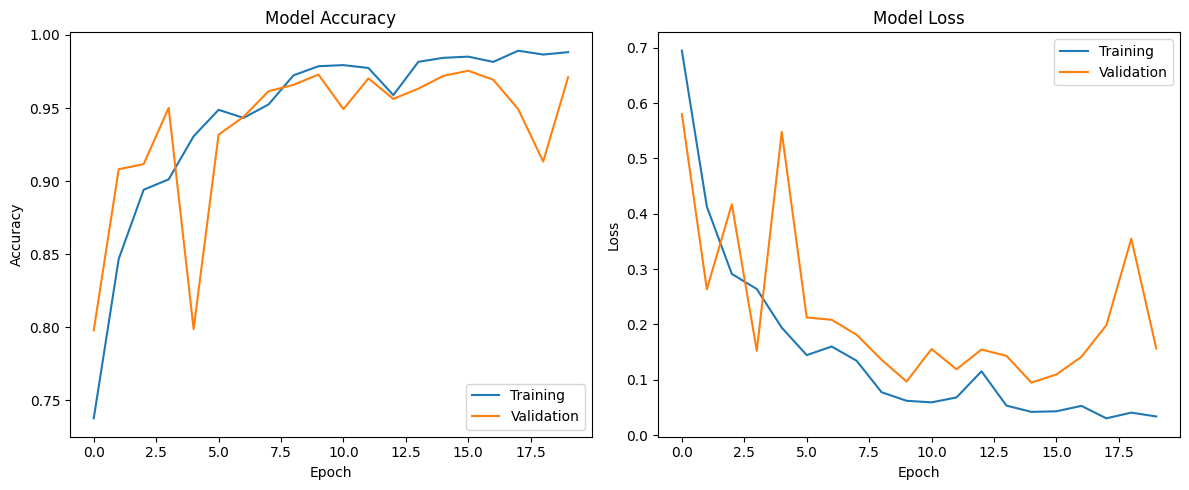

In [53]:
# Load the best model
from tensorflow.keras.models import load_model
cnn_best_model = load_model(os.path.join(cnn_model_dir, f"{model_name}.keras"))

# Visualize training history
def plot_training_history(history):
    plt.figure(figsize=(12, 5))

    # Accuracy
    plt.subplot(1, 2, 1)
    plt.plot(history.history['accuracy'])
    plt.plot(history.history['val_accuracy'])
    plt.title('Model Accuracy')
    plt.ylabel('Accuracy')
    plt.xlabel('Epoch')
    plt.legend(['Training', 'Validation'], loc='lower right')

    # Loss
    plt.subplot(1, 2, 2)
    plt.plot(history.history['loss'])
    plt.plot(history.history['val_loss'])
    plt.title('Model Loss')
    plt.ylabel('Loss')
    plt.xlabel('Epoch')
    plt.legend(['Training', 'Validation'], loc='upper right')

    plt.tight_layout()
    plt.savefig(os.path.join(cnn_model_dir, f"{model_name}_history.png"))
    plt.show()

plot_training_history(cnn_history)

41/41 [==============================] - 1s 6ms/step - loss: 0.0992 - accuracy: 0.9779
Test accuracy: 97.79%
Test loss: 0.0992
41/41 [==============================] - 0s 5ms/step


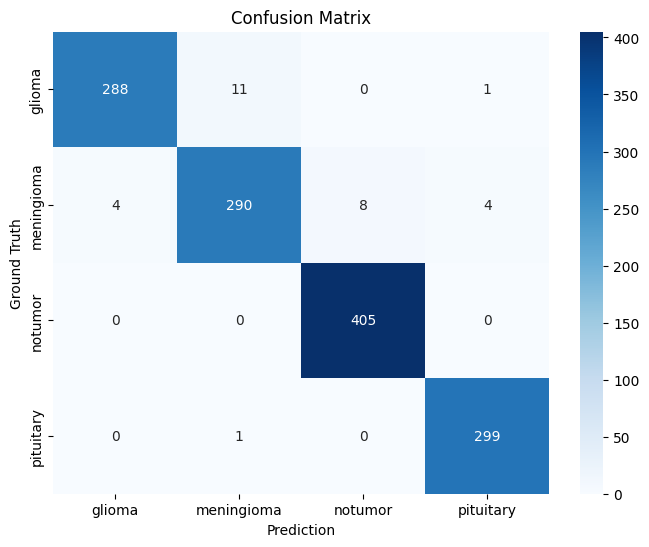

In [54]:
# Evaluate the model on the test set
test_loss, test_accuracy = cnn_best_model.evaluate(X_test, y_test, verbose=1)
print(f"Test accuracy: {test_accuracy*100:.2f}%")
print(f"Test loss: {test_loss:.4f}")

# Get predictions
y_pred = cnn_best_model.predict(X_test)
y_pred_classes = np.argmax(y_pred, axis=1)
y_test_classes = np.argmax(y_test, axis=1)

# Calculate confusion matrix
conf_matrix = confusion_matrix(y_test_classes, y_pred_classes)

# Display confusion matrix
plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues',
            xticklabels=classes, yticklabels=classes)
plt.xlabel('Prediction')
plt.ylabel('Ground Truth')
plt.title('Confusion Matrix')
plt.savefig(os.path.join(cnn_model_dir, f"{model_name}_confusion_matrix.png"))
plt.show()

In [55]:
# Display classification report
class_report = classification_report(y_test_classes, y_pred_classes, target_names=classes)
print("Classification Report:")
print(class_report)

# Calculate AUC (Area Under the ROC Curve) for multiclass
auc_scores = []
for i in range(num_classes):
    auc_scores.append(roc_auc_score(y_test[:, i], y_pred[:, i]))
print("AUC scores per class:")
for i, score in enumerate(auc_scores):
    print(f"{classes[i]}: {score:.4f}")
print(f"Average AUC: {np.mean(auc_scores):.4f}")

# Save evaluation metrics
import json

# Convert classification report to dictionary
class_report_dict = classification_report(y_test_classes, y_pred_classes, target_names=classes, output_dict=True)

results = {
    'test_loss': float(test_loss),
    'test_accuracy': float(test_accuracy),
    'confusion_matrix': conf_matrix.tolist(),
    'classification_report': class_report_dict,
    'auc_per_class': {classes[i]: float(score) for i, score in enumerate(auc_scores)},
    'average_auc': float(np.mean(auc_scores))
}

with open(os.path.join(cnn_model_dir, f"{model_name}_evaluation.json"), 'w') as f:
    json.dump(results, f, indent=4)

print(f"Evaluation results saved to {cnn_model_dir}/{model_name}_evaluation.json")

Classification Report:
              precision    recall  f1-score   support

      glioma       0.99      0.96      0.97       300
  meningioma       0.96      0.95      0.95       306
     notumor       0.98      1.00      0.99       405
   pituitary       0.98      1.00      0.99       300

    accuracy                           0.98      1311
   macro avg       0.98      0.98      0.98      1311
weighted avg       0.98      0.98      0.98      1311

AUC scores per class:
glioma: 0.9993
meningioma: 0.9934
notumor: 0.9992
pituitary: 0.9997
Average AUC: 0.9979
Evaluation results saved to ./BrainTumorClassification\models\cnn_base/brain_tumor_cnn_base_evaluation.json


## 5. Transfer Learning with EfficientNet
Using pre-trained EfficientNetV2B0 for brain tumor classification

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras.applications import EfficientNetV2B0
from tensorflow.keras.models import Model, load_model
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D, Dropout, BatchNormalization
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping, ReduceLROnPlateau
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score
import seaborn as sns

# Parameters
tl_model_dir = os.path.join(models_dir, 'transfer_learning')
os.makedirs(tl_model_dir, exist_ok=True)
model_name = 'brain_tumor_efficientnet'
input_shape = (128, 128, 3)
num_classes = 4
batch_size = 16
epochs = 20

# Load the data
X_train = np.load(os.path.join(augmented_dir, 'X_train_aug.npy'))
y_train = np.load(os.path.join(augmented_dir, 'y_train_aug.npy'))
X_val = np.load(os.path.join(augmented_dir, 'X_val.npy'))
y_val = np.load(os.path.join(augmented_dir, 'y_val.npy'))
X_test = np.load(os.path.join(augmented_dir, 'X_test.npy'))
y_test = np.load(os.path.join(augmented_dir, 'y_test.npy'))

with open(os.path.join(augmented_dir, 'classes.txt'), 'r') as f:
    classes = [line.strip() for line in f.readlines()]

print(f"Data loaded - X_train: {X_train.shape}, y_train: {y_train.shape}")
print(f"Classes: {classes}")

Data loaded - X_train: (18276, 128, 128, 3), y_train: (18276, 4)
Classes: ['glioma', 'meningioma', 'notumor', 'pituitary']


In [ ]:
# Create the transfer learning model
def create_transfer_model(input_shape, num_classes):
    # Load pre-trained model without fully-connected layers
    base_model = EfficientNetV2B0(weights='imagenet', include_top=False, input_shape=input_shape)

    # Freeze all layers in the base model
    for layer in base_model.layers:
        layer.trainable = False

    # Add custom layers
    x = base_model.output
    x = GlobalAveragePooling2D()(x)
    x = Dense(512, activation='relu')(x)
    x = BatchNormalization()(x)
    x = Dropout(0.5)(x)
    predictions = Dense(num_classes, activation='softmax')(x)

    # Create the final model
    model = Model(inputs=base_model.input, outputs=predictions)

    # Compile the model
    model.compile(
        optimizer=Adam(learning_rate=0.001),
        loss='categorical_crossentropy',
        metrics=['accuracy']
    )

    return model, base_model

# Create the model
efficientnet_model, base_model = create_transfer_model(input_shape, num_classes)
efficientnet_model.summary()

Model: "model"
__________________________________________________________________________________________________
 Layer (type)                   Output Shape         Param #     Connected to                     
 input_1 (InputLayer)           [(None, 128, 128, 3  0           []                               
                                )]                                                                
                                                                                                  
 rescaling (Rescaling)          (None, 128, 128, 3)  0           ['input_1[0][0]']                
                                                                                                  
 normalization (Normalization)  (None, 128, 128, 3)  0           ['rescaling[0][0]']              
                                                                                                  
 stem_conv (Conv2D)             (None, 64, 64, 32)   864         ['normalization[0][0]']      

In [ ]:
checkpoint_phase1 = ModelCheckpoint(
    filepath=os.path.join(tl_model_dir, f"{model_name}_initial.keras"),
    monitor='val_accuracy',
    mode='max',
    save_best_only=True,
    verbose=1
)

early_stopping = EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True,
    verbose=1
)
reduce_lr = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.2,
    patience=3,
    min_lr=1e-6,
    verbose=1
)
callbacks_phase1 = [checkpoint_phase1, early_stopping, reduce_lr]

# Phase 1: Train only the top layers
# Clear previous memory
clear_memory()

# Create optimized datasets with smaller batch size for larger model
train_dataset = create_dataset(X_train_aug, y_train_aug, batch_size=16, is_training=True)
val_dataset = create_dataset(X_val, y_val, batch_size=16)

# Phase 1: Train only the top layers
print("Phase 1: Training with frozen base model")
history_initial = cnn_model.fit(
    train_dataset,
    validation_data=val_dataset,
    epochs=epochs,
    callbacks=callbacks_phase1,
    verbose=1
)

Memory cleared
Phase 1: Training with frozen base model
Epoch 1/20
1143/1143 [==============================] - ETA: 0s - loss: 0.6903 - accuracy: 0.7395
Epoch 1: val_accuracy improved from -inf to 0.77603, saving model to ./BrainTumorClassification\models\transfer_learning\brain_tumor_efficientnet_initial.keras
1143/1143 [==============================] - 20s 16ms/step - loss: 0.6903 - accuracy: 0.7395 - val_loss: 0.5818 - val_accuracy: 0.7760 - lr: 0.0010
Epoch 2/20
1140/1143 [============================>.] - ETA: 0s - loss: 0.5370 - accuracy: 0.7938
Epoch 2: val_accuracy improved from 0.77603 to 0.87577, saving model to ./BrainTumorClassification\models\transfer_learning\brain_tumor_efficientnet_initial.keras
1143/1143 [==============================] - 18s 16ms/step - loss: 0.5377 - accuracy: 0.7937 - val_loss: 0.4171 - val_accuracy: 0.8758 - lr: 0.0010
Epoch 3/20
1141/1143 [============================>.] - ETA: 0s - loss: 0.5285 - accuracy: 0.7981
Epoch 3: val_accuracy did not i

In [ ]:
# Phase 2: Fine-tuning
print("Phase 2: Fine-tuning the last layers")

# Unfreeze the last 20 layers
n_custom = 5
n_finetune = 20
start = len(efficientnet_model.layers) - n_custom - n_finetune
end = len(efficientnet_model.layers) - n_custom

for layer in efficientnet_model.layers[start:end]:
    if not isinstance(layer, tf.keras.layers.BatchNormalization):
        layer.trainable = True

# Recompile with lower learning rate
efficientnet_model.compile(
    optimizer=Adam(1e-4),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

# Callbacks for Phase 2
checkpoint_phase2 = ModelCheckpoint(
    filepath=os.path.join(tl_model_dir, f"{model_name}_final.keras"),
    monitor='val_accuracy',
    mode='max',
    save_best_only=True,
    verbose=1
)
callbacks_phase2 = [checkpoint_phase2, early_stopping, reduce_lr]


# Launch fine-tuning
# Clear memory
clear_memory()

# Create even smaller batch datasets for fine-tuning
train_dataset = create_dataset(X_train_aug, y_train_aug, batch_size=16, is_training=True)
val_dataset = create_dataset(X_val, y_val, batch_size=16)

# Launch fine-tuning
history_finetune = efficientnet_model.fit(
    train_dataset,
    validation_data=val_dataset,
    epochs=epochs,
    callbacks=callbacks_phase2,
    verbose=1
)

# Save checkpoint
save_checkpoint('efficientnet_training')

Phase 2: Fine-tuning the last layers
Memory cleared
Epoch 1/20
1143/1143 [==============================] - ETA: 0s - loss: 1.5463 - accuracy: 0.3119
Epoch 1: val_accuracy improved from -inf to 0.36570, saving model to ./BrainTumorClassification\models\transfer_learning\brain_tumor_efficientnet_final.keras
1143/1143 [==============================] - 111s 94ms/step - loss: 1.5463 - accuracy: 0.3119 - val_loss: 1.3826 - val_accuracy: 0.3657 - lr: 1.0000e-04
Epoch 2/20
1143/1143 [==============================] - ETA: 0s - loss: 1.4223 - accuracy: 0.3492
Epoch 2: val_accuracy did not improve from 0.36570
1143/1143 [==============================] - 102s 90ms/step - loss: 1.4223 - accuracy: 0.3492 - val_loss: 1.7623 - val_accuracy: 0.2353 - lr: 1.0000e-04
Epoch 3/20
1143/1143 [==============================] - ETA: 0s - loss: 1.3514 - accuracy: 0.3758

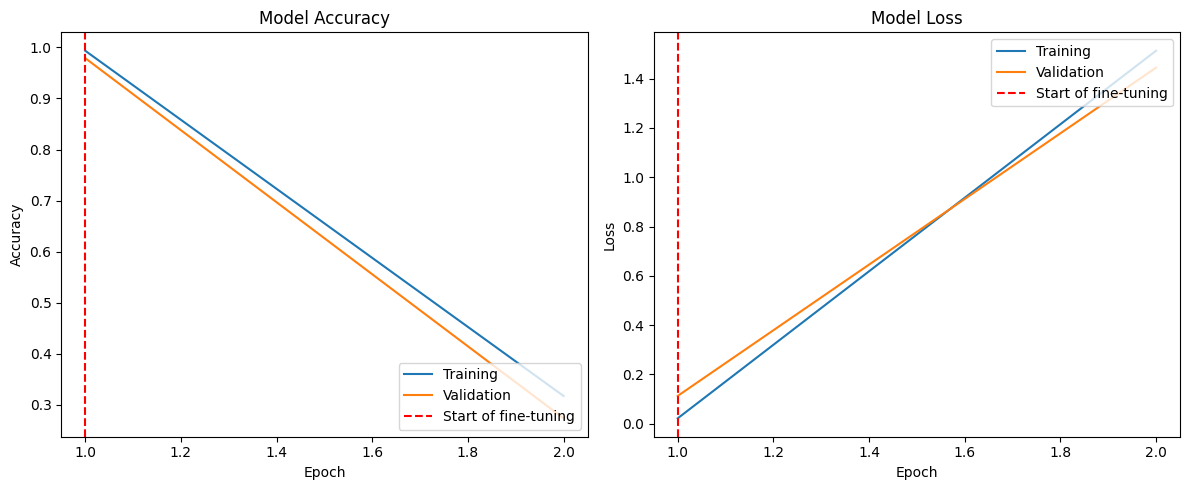

In [ ]:
# Load the best model after Phase 2
efficientnet_best_model = load_model(os.path.join(tl_model_dir, f"{model_name}_final.keras"))

# Visualize training history
def plot_training_history(history_initial, history_finetune):
    # Combine histories
    combined_acc = history_initial.history['accuracy'] + history_finetune.history['accuracy']
    combined_val_acc = history_initial.history['val_accuracy'] + history_finetune.history['val_accuracy']
    combined_loss = history_initial.history['loss'] + history_finetune.history['loss']
    combined_val_loss = history_initial.history['val_loss'] + history_finetune.history['val_loss']

    epochs_initial = len(history_initial.history['accuracy'])
    epochs_total = len(combined_acc)
    epochs_range = range(1, epochs_total + 1)

    plt.figure(figsize=(12, 5))

    # Accuracy
    plt.subplot(1, 2, 1)
    plt.plot(epochs_range, combined_acc)
    plt.plot(epochs_range, combined_val_acc)
    plt.axvline(x=epochs_initial, color='r', linestyle='--')
    plt.title('Model Accuracy')
    plt.ylabel('Accuracy')
    plt.xlabel('Epoch')
    plt.legend(['Training', 'Validation', 'Start of fine-tuning'], loc='lower right')

    # Loss
    plt.subplot(1, 2, 2)
    plt.plot(epochs_range, combined_loss)
    plt.plot(epochs_range, combined_val_loss)
    plt.axvline(x=epochs_initial, color='r', linestyle='--')
    plt.title('Model Loss')
    plt.ylabel('Loss')
    plt.xlabel('Epoch')
    plt.legend(['Training', 'Validation', 'Start of fine-tuning'], loc='upper right')

    plt.tight_layout()
    plt.savefig(os.path.join(tl_model_dir, f"{model_name}_history.png"))
    plt.show()

plot_training_history(history_initial, history_finetune)

41/41 [==============================] - 5s 86ms/step - loss: 1.4954 - accuracy: 0.2578
Test accuracy: 25.78%
Test loss: 1.4954
41/41 [==============================] - 4s 82ms/step


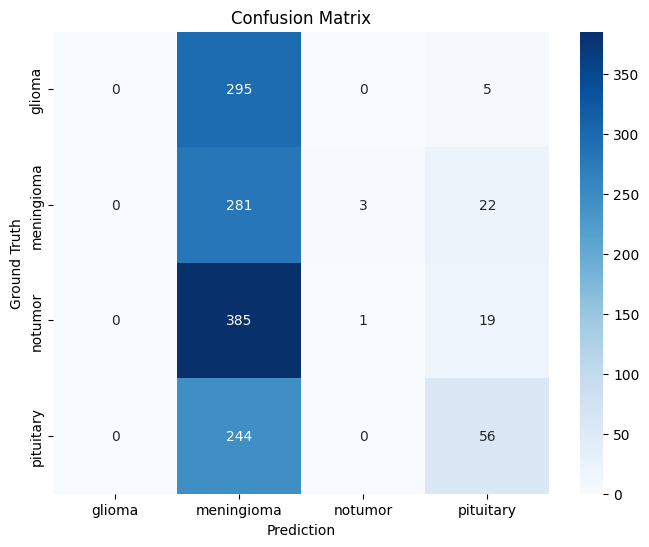

In [ ]:
# Evaluate the model on the test set
test_loss, test_accuracy = efficientnet_best_model.evaluate(X_test, y_test, verbose=1)
print(f"Test accuracy: {test_accuracy*100:.2f}%")
print(f"Test loss: {test_loss:.4f}")

# Get predictions
y_pred = efficientnet_best_model.predict(X_test)
y_pred_cls = np.argmax(y_pred, axis=1)
y_true_cls = np.argmax(y_test, axis=1)

# Confusion matrix
cm = confusion_matrix(y_true_cls, y_pred_cls)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d',
           xticklabels=classes, yticklabels=classes,
           cmap='Blues')
plt.xlabel('Prediction')
plt.ylabel('Ground Truth')
plt.title('Confusion Matrix')
plt.savefig(os.path.join(tl_model_dir, f"{model_name}_confusion_matrix.png"))
plt.show()

In [ ]:
# Classification report
print(classification_report(y_true_cls, y_pred_cls, target_names=classes))

# AUC for multiclass
auc_scores = []
for i in range(num_classes):
    auc_scores.append(roc_auc_score(y_test[:, i], y_pred[:, i]))
print("AUC scores per class:")
for i, score in enumerate(auc_scores):
    print(f"{classes[i]}: {score:.4f}")
print(f"Average AUC: {np.mean(auc_scores):.4f}")

# Save evaluation results
report_dict = classification_report(
    y_true_cls,
    y_pred_cls,
    target_names=classes,
    output_dict=True
)

# Build results dictionary
results = {
    'test_loss': float(test_loss),
    'test_accuracy': float(test_accuracy),
    'confusion_matrix': cm.tolist(),
    'classification_report': report_dict,
    'auc_per_class': {classes[i]: float(score) for i, score in enumerate(auc_scores)},
    'average_auc': float(np.mean(auc_scores))
}

# Save to json
output_json = os.path.join(tl_model_dir, f"{model_name}_evaluation.json")
with open(output_json, 'w') as f:
    json.dump(results, f, indent=4)

print(f"Metrics saved to: {output_json}")

              precision    recall  f1-score   support

      glioma       0.00      0.00      0.00       300
  meningioma       0.23      0.92      0.37       306
     notumor       0.25      0.00      0.00       405
   pituitary       0.55      0.19      0.28       300

    accuracy                           0.26      1311
   macro avg       0.26      0.28      0.16      1311
weighted avg       0.26      0.26      0.15      1311

AUC scores per class:
glioma: 0.7614
meningioma: 0.6113
notumor: 0.6911
pituitary: 0.8093
Average AUC: 0.7183
Metrics saved to: ./BrainTumorClassification\models\transfer_learning\brain_tumor_efficientnet_evaluation.json


c:\Users\raedb\.conda\envs\colab-gpu\lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
c:\Users\raedb\.conda\envs\colab-gpu\lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
c:\Users\raedb\.conda\envs\colab-gpu\lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
c:\U

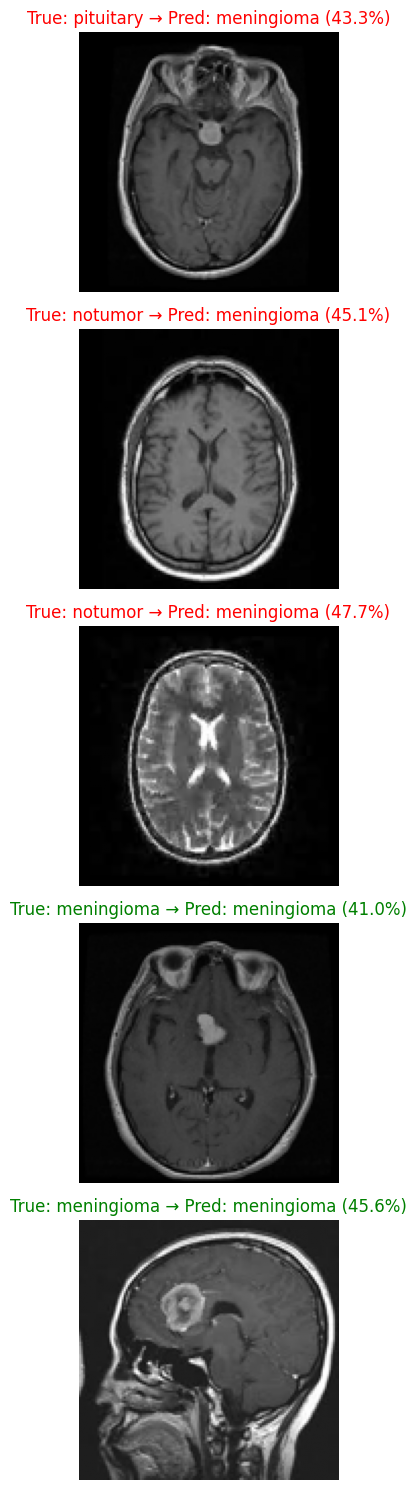

In [ ]:
# Visualize some predictions
def plot_some_preds(X, y_true, y_pred, classes, n=5):
    idx = np.random.choice(len(X), n, replace=False)
    plt.figure(figsize=(6, 3*n))
    for i, j in enumerate(idx, 1):
        true_c = np.argmax(y_true[j])
        pred_c = np.argmax(y_pred[j])
        conf = y_pred[j][pred_c]*100
        plt.subplot(n, 1, i)
        plt.imshow(X[j])
        plt.title(f"True: {classes[true_c]} → Pred: {classes[pred_c]} ({conf:.1f}%)",
                 color=('green' if true_c==pred_c else 'red'))
        plt.axis('off')
    plt.tight_layout()
    plt.savefig(os.path.join(tl_model_dir, f"{model_name}_predictions.png"))
    plt.show()

plot_some_preds(X_test, y_test, y_pred, classes)

## 6. MobileNetV2 Model
Using pre-trained MobileNetV2 for brain tumor classification

In [ ]:
import os
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D, Dropout, BatchNormalization
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping, ReduceLROnPlateau
from sklearn.metrics import classification_report, confusion_matrix

# Parameters
mobilenet_model_dir = os.path.join(models_dir, 'mobilenet')
os.makedirs(mobilenet_model_dir, exist_ok=True)
model_name = 'brain_tumor_mobilenet'
input_shape = (128, 128, 3)
num_classes = 4
batch_size = 4
epochs = 20

# Load the augmented data
X_train = np.load(os.path.join(augmented_dir, 'X_train_aug.npy'))
y_train = np.load(os.path.join(augmented_dir, 'y_train_aug.npy'))
X_val = np.load(os.path.join(augmented_dir, 'X_val.npy'))
y_val = np.load(os.path.join(augmented_dir, 'y_val.npy'))
X_test = np.load(os.path.join(augmented_dir, 'X_test.npy'))
y_test = np.load(os.path.join(augmented_dir, 'y_test.npy'))

with open(os.path.join(augmented_dir, 'classes.txt'), 'r') as f:
    classes = [line.strip() for line in f.readlines()]

print(f"Data loaded - X_train: {X_train.shape}, y_train: {y_train.shape}")
print(f"Classes: {classes}")

Data loaded - X_train: (18276, 128, 128, 3), y_train: (18276, 4)
Classes: ['glioma', 'meningioma', 'notumor', 'pituitary']


In [ ]:
# Create the MobileNetV2 model
def create_mobilenet_model(input_shape, num_classes):
    # Load pre-trained model without fully-connected layer
    base_model = MobileNetV2(weights='imagenet', include_top=False, input_shape=input_shape)

    # Freeze all layers in the base model
    for layer in base_model.layers:
        layer.trainable = False

    # Add custom layers
    x = base_model.output
    x = GlobalAveragePooling2D()(x)
    x = Dense(256, activation='relu')(x)
    x = BatchNormalization()(x)
    x = Dropout(0.5)(x)
    predictions = Dense(num_classes, activation='softmax')(x)

    # Create the final model
    model = Model(inputs=base_model.input, outputs=predictions)

    # Compile the model
    model.compile(
        optimizer=Adam(learning_rate=0.001),
        loss='categorical_crossentropy',
        metrics=['accuracy']
    )

    return model

# Create the model
mobilenet_model = create_mobilenet_model(input_shape, num_classes)
mobilenet_model.summary()

9406464/9406464 [==============================] - 9s 1us/step
Model: "model"
__________________________________________________________________________________________________
 Layer (type)                   Output Shape         Param #     Connected to                     
 input_1 (InputLayer)           [(None, 128, 128, 3  0           []                               
                                )]                                                                
                                                                                                  
 Conv1 (Conv2D)                 (None, 64, 64, 32)   864         ['input_1[0][0]']                
                                                                                                  
 bn_Conv1 (BatchNormalization)  (None, 64, 64, 32)   128         ['Conv1[0][0]']                  
                                                                                                  
 Conv1_relu (ReLU)             

In [ ]:
# Configure callbacks
checkpoint = ModelCheckpoint(
    os.path.join(mobilenet_model_dir, f"{model_name}_initial.keras"),
    monitor='val_accuracy',
    mode='max',
    save_best_only=True,
    verbose=1
)

early_stopping = EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True,
    verbose=1
)

reduce_lr = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.2,
    patience=3,
    min_lr=1e-6,
    verbose=1
)

callbacks = [checkpoint, early_stopping, reduce_lr]

# Clear memory
clear_memory()

# Create datasets
train_dataset = create_dataset(X_train_aug, y_train_aug, batch_size=24, is_training=True)
val_dataset = create_dataset(X_val, y_val, batch_size=24)

# Phase 1: Training with base layers frozen
print("Phase 1: Training with base layers frozen")
history_initial = mobilenet_model.fit(
    train_dataset,
    validation_data=val_dataset,
    epochs=5,
    callbacks=callbacks,
    verbose=1
)

Memory cleared
Phase 1: Training with base layers frozen
762/762 [==============================] - ETA: 0s - loss: 0.3715 - accuracy: 0.8637
Epoch 1: val_accuracy improved from -inf to 0.90726, saving model to ./BrainTumorClassification\models\mobilenet\brain_tumor_mobilenet_initial.keras
762/762 [==============================] - 46s 60ms/step - loss: 0.3715 - accuracy: 0.8637 - val_loss: 0.2513 - val_accuracy: 0.9073 - lr: 0.0010


In [ ]:
# Phase 2: Fine-tuning the last layers of the base model
print("Phase 2: Fine-tuning")

# Unfreeze the last few layers of the base model
fine_tune_layers = 20
for layer in mobilenet_model.layers[-fine_tune_layers:]:
    if not isinstance(layer, tf.keras.layers.BatchNormalization):
        layer.trainable = True

# Recompile with a lower learning rate
mobilenet_model.compile(
    optimizer=Adam(learning_rate=0.0001),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

# Update checkpoint for phase 2
checkpoint_phase2 = ModelCheckpoint(
    os.path.join(mobilenet_model_dir, f"{model_name}_final.keras"),
    monitor='val_accuracy',
    mode='max',
    save_best_only=True,
    verbose=1
)
callbacks_phase2 = [checkpoint_phase2, early_stopping, reduce_lr]

# Launch fine-tuning
# Clear memory
clear_memory()

# Create datasets with smaller batch size
train_dataset = create_dataset(X_train_aug, y_train_aug, batch_size=16, is_training=True)
val_dataset = create_dataset(X_val, y_val, batch_size=16)

# Launch fine-tuning
history_finetune = mobilenet_model.fit(
    train_dataset,
    validation_data=val_dataset,
    epochs=20,
    callbacks=callbacks_phase2,
    verbose=1
)

# Save checkpoint
save_checkpoint('mobilenet_training')

Phase 2: Fine-tuning
Memory cleared
1143/1143 [==============================] - ETA: 0s - loss: 0.4178 - accuracy: 0.8461
Epoch 1: val_accuracy improved from -inf to 0.24059, saving model to ./BrainTumorClassification\models\mobilenet\brain_tumor_mobilenet_final.keras
1143/1143 [==============================] - 65s 55ms/step - loss: 0.4178 - accuracy: 0.8461 - val_loss: 6.0312 - val_accuracy: 0.2406 - lr: 1.0000e-04
Checkpoint saved for phase: mobilenet_training


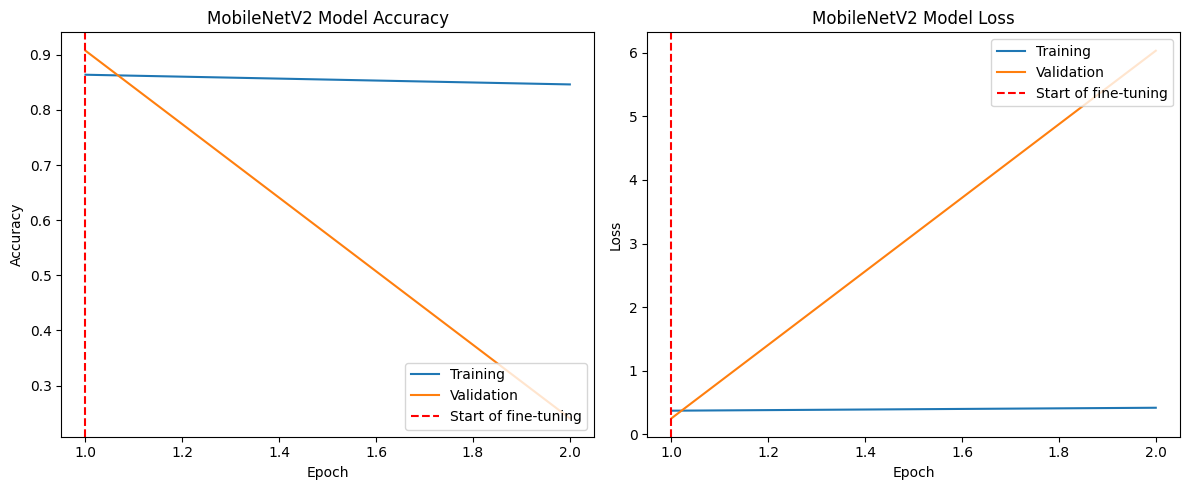

In [ ]:
# Load best model
mobilenet_best_model = load_model(os.path.join(mobilenet_model_dir, f"{model_name}_final.keras"))

# Save learning curves
def plot_training_history(history_initial, history_finetune):
    # Combine histories
    combined_acc = history_initial.history['accuracy'] + history_finetune.history['accuracy']
    combined_val_acc = history_initial.history['val_accuracy'] + history_finetune.history['val_accuracy']
    combined_loss = history_initial.history['loss'] + history_finetune.history['loss']
    combined_val_loss = history_initial.history['val_loss'] + history_finetune.history['val_loss']

    epochs_initial = len(history_initial.history['accuracy'])
    epochs_total = len(combined_acc)
    epochs_range = range(1, epochs_total + 1)

    plt.figure(figsize=(12, 5))

    # Accuracy
    plt.subplot(1, 2, 1)
    plt.plot(epochs_range, combined_acc)
    plt.plot(epochs_range, combined_val_acc)
    plt.axvline(x=epochs_initial, color='r', linestyle='--')
    plt.title('MobileNetV2 Model Accuracy')
    plt.ylabel('Accuracy')
    plt.xlabel('Epoch')
    plt.legend(['Training', 'Validation', 'Start of fine-tuning'], loc='lower right')

    # Loss
    plt.subplot(1, 2, 2)
    plt.plot(epochs_range, combined_loss)
    plt.plot(epochs_range, combined_val_loss)
    plt.axvline(x=epochs_initial, color='r', linestyle='--')
    plt.title('MobileNetV2 Model Loss')
    plt.ylabel('Loss')
    plt.xlabel('Epoch')
    plt.legend(['Training', 'Validation', 'Start of fine-tuning'], loc='upper right')

    plt.tight_layout()
    plt.savefig(os.path.join(mobilenet_model_dir, f"{model_name}_history.png"))
    plt.show()

plot_training_history(history_initial, history_finetune)

Evaluating model on test set...
41/41 [==============================] - 3s 50ms/step - loss: 6.0164 - accuracy: 0.2365
Test accuracy: 23.65%
Test loss: 6.0164
41/41 [==============================] - 2s 47ms/step


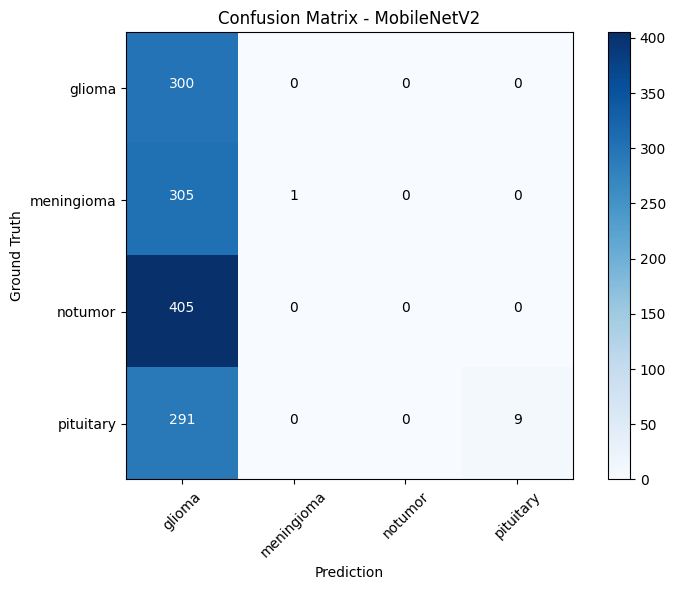

In [ ]:
# Evaluate the final model on the test set
print("Evaluating model on test set...")
test_loss, test_accuracy = mobilenet_best_model.evaluate(X_test, y_test, verbose=1)
print(f"Test accuracy: {test_accuracy*100:.2f}%")
print(f"Test loss: {test_loss:.4f}")

# Get predictions
y_pred = mobilenet_best_model.predict(X_test)
y_pred_classes = np.argmax(y_pred, axis=1)
y_test_classes = np.argmax(y_test, axis=1)

# Confusion matrix
cm = confusion_matrix(y_test_classes, y_pred_classes)
plt.figure(figsize=(8, 6))
plt.imshow(cm, interpolation='nearest', cmap=plt.cm.Blues)
plt.title('Confusion Matrix - MobileNetV2')
plt.colorbar()
tick_marks = np.arange(len(classes))
plt.xticks(tick_marks, classes, rotation=45)
plt.yticks(tick_marks, classes)
plt.xlabel('Prediction')
plt.ylabel('Ground Truth')

# Add numbers on matrix
thresh = cm.max() / 2.
for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        plt.text(j, i, format(cm[i, j], 'd'),
                 horizontalalignment="center",
                 color="white" if cm[i, j] > thresh else "black")

plt.tight_layout()
plt.savefig(os.path.join(mobilenet_model_dir, f"{model_name}_confusion_matrix.png"))
plt.show()

In [ ]:
# Classification report
print("Classification Report:")
print(classification_report(y_test_classes, y_pred_classes, target_names=classes))

# AUC for multiclass
auc_scores = []
for i in range(num_classes):
    auc_scores.append(roc_auc_score(y_test[:, i], y_pred[:, i]))
print("AUC scores per class:")
for i, score in enumerate(auc_scores):
    print(f"{classes[i]}: {score:.4f}")
print(f"Average AUC: {np.mean(auc_scores):.4f}")

# Save evaluation metrics
report_dict = classification_report(y_test_classes, y_pred_classes, target_names=classes, output_dict=True)

results = {
    'test_loss': float(test_loss),
    'test_accuracy': float(test_accuracy),
    'confusion_matrix': cm.tolist(),
    'classification_report': report_dict,
    'auc_per_class': {classes[i]: float(score) for i, score in enumerate(auc_scores)},
    'average_auc': float(np.mean(auc_scores))
}

with open(os.path.join(mobilenet_model_dir, f"{model_name}_evaluation.json"), 'w') as f:
    json.dump(results, f, indent=4)

print(f"Evaluation results saved to {mobilenet_model_dir}/{model_name}_evaluation.json")

Classification Report:
              precision    recall  f1-score   support

      glioma       0.23      1.00      0.37       300
  meningioma       1.00      0.00      0.01       306
     notumor       0.00      0.00      0.00       405
   pituitary       1.00      0.03      0.06       300

    accuracy                           0.24      1311
   macro avg       0.56      0.26      0.11      1311
weighted avg       0.52      0.24      0.10      1311

AUC scores per class:
glioma: 0.8127
meningioma: 0.8098
notumor: 0.9739
pituitary: 0.9617
Average AUC: 0.8895
Evaluation results saved to ./BrainTumorClassification\models\mobilenet/brain_tumor_mobilenet_evaluation.json


c:\Users\raedb\.conda\envs\colab-gpu\lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
c:\Users\raedb\.conda\envs\colab-gpu\lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
c:\Users\raedb\.conda\envs\colab-gpu\lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
c:\U

## 7. Model Comparison
Compare performance of all trained models

In [57]:
import os
import glob
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from tensorflow.keras.models import load_model
from sklearn.metrics import roc_curve, auc, confusion_matrix, classification_report

# Create comparison directory
comparison_dir = os.path.join(models_dir, 'comparison')
os.makedirs(comparison_dir, exist_ok=True)

# Load test data and classes
X_test = np.load(os.path.join(augmented_dir, 'X_test.npy'))
y_test = np.load(os.path.join(augmented_dir, 'y_test.npy'))

with open(os.path.join(augmented_dir, 'classes.txt'), 'r') as f:
    classes = [line.strip() for line in f]

print(f"Test data: X_test = {X_test.shape}, y_test = {y_test.shape}")
print(f"Classes: {classes}")

# Configure models to compare
models_info = [
    {
        'name': 'Base CNN',
        'dir': os.path.join(models_dir, 'cnn_base'),
        'file': 'brain_tumor_cnn_base.keras'
    },
    {
        'name': 'EfficientNet',
        'dir': os.path.join(models_dir, 'transfer_learning'),
        'file': 'brain_tumor_efficientnet_final.keras'
    },
    {
        'name': 'MobileNetV2',
        'dir': os.path.join(models_dir, 'mobilenet'),
        'file': 'brain_tumor_mobilenet_final.keras'
    }
]

# Check for model files
for info in models_info[:]:
    model_path = os.path.join(info['dir'], info['file'])
    if not os.path.exists(model_path):
        print(f"⚠️ Model not found: {model_path}")
        models_info.remove(info)
    else:
        print(f"✓ Model found: {model_path}")

if not models_info:
    raise RuntimeError("No models found. Check your paths.")

Test data: X_test = (1311, 128, 128, 3), y_test = (1311, 4)
Classes: ['glioma', 'meningioma', 'notumor', 'pituitary']
✓ Model found: ./BrainTumorClassification\models\cnn_base\brain_tumor_cnn_base.keras
✓ Model found: ./BrainTumorClassification\models\transfer_learning\brain_tumor_efficientnet_final.keras
✓ Model found: ./BrainTumorClassification\models\mobilenet\brain_tumor_mobilenet_final.keras


In [58]:
# Evaluate each model
metrics = []
cm_dict = {}  # To store confusion matrices
predictions = {}  # To store predictions of each model

# Create test dataset once
test_dataset = create_dataset(X_test, y_test, batch_size=16)
y_true_classes = np.argmax(y_test, axis=1)

for info in models_info:
    model_path = os.path.join(info['dir'], info['file'])
    print(f"\nEvaluating model: {info['name']}")

    # Clear memory before loading next model
    clear_memory()

    try:
        # Load model
        model = load_model(model_path)

        # Evaluate
        test_loss, test_accuracy = model.evaluate(X_test, y_test, verbose=1)

        # Predictions
        y_pred = model.predict(X_test, batch_size=16)
        y_pred_classes = np.argmax(y_pred, axis=1)
        y_true_classes = np.argmax(y_test, axis=1)

        # Store predictions for later use
        predictions[info['name']] = {
            'y_pred': y_pred,
            'y_pred_classes': y_pred_classes
        }

        # Confusion matrix
        cm = confusion_matrix(y_true_classes, y_pred_classes)
        cm_dict[info['name']] = cm

        # Classification report
        report = classification_report(y_true_classes, y_pred_classes,
                                      target_names=classes, output_dict=True)

        # Calculate ROC curve for each class
        auc_scores = []
        for i in range(len(classes)):
            if len(np.unique(y_test[:, i])) == 2:  # Ensure there are two classes
                fpr, tpr, _ = roc_curve(y_test[:, i], y_pred[:, i])
                auc_scores.append(auc(fpr, tpr))
            else:
                auc_scores.append(0)

        mean_auc = np.mean(auc_scores)

        # Add metrics
        metrics.append({
            'Model': info['name'],
            'Accuracy': test_accuracy * 100,
            'Loss': test_loss,
            'Mean AUC': mean_auc,
            'F1-Score': report['weighted avg']['f1-score'],
            'Precision': report['weighted avg']['precision'],
            'Recall': report['weighted avg']['recall'],
        })

        # Per-class report
        print("\nPer-class performance:")
        for cls in classes:
            print(f"{cls}: F1={report[cls]['f1-score']:.4f}, "
                 f"Precision={report[cls]['precision']:.4f}, "
                 f"Recall={report[cls]['recall']:.4f}")
            
        # Delete model to free memory
        del model
        gc.collect()
    except Exception as e:
        print(f"⚠️ Error evaluating {info['name']}: {e}")

# Create comparison DataFrame
metrics_df = pd.DataFrame(metrics)
print("\nMetrics comparison:")
print(metrics_df)

# Save to CSV
metrics_df.to_csv(os.path.join(comparison_dir, 'model_comparison.csv'), index=False)


Evaluating model: Base CNN
Memory cleared
82/82 [==============================] - 0s 3ms/step

Per-class performance:
glioma: F1=0.9730, Precision=0.9863, Recall=0.9600
meningioma: F1=0.9539, Precision=0.9603, Recall=0.9477
notumor: F1=0.9902, Precision=0.9806, Recall=1.0000
pituitary: F1=0.9901, Precision=0.9836, Recall=0.9967

Evaluating model: EfficientNet
Memory cleared
82/82 [==============================] - 7s 78ms/step

Per-class performance:
glioma: F1=0.5815, Precision=0.5400, Recall=0.6300
meningioma: F1=0.3368, Precision=0.4530, Recall=0.2680
notumor: F1=0.6183, Precision=0.8559, Recall=0.4840
pituitary: F1=0.6251, Precision=0.4828, Recall=0.8867

Evaluating model: MobileNetV2
Memory cleared
82/82 [==============================] - 4s 45ms/step

Per-class performance:
glioma: F1=0.9263, Precision=0.9778, Recall=0.8800
meningioma: F1=0.9146, Precision=0.8865, Recall=0.9444
notumor: F1=0.9890, Precision=0.9806, Recall=0.9975
pituitary: F1=0.9851, Precision=0.9802, Recall=0.

C:\Users\raedb\AppData\Local\Temp\ipykernel_31360\3205484865.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(x='Model', y='Accuracy', data=metrics_df, palette='viridis')
C:\Users\raedb\AppData\Local\Temp\ipykernel_31360\3205484865.py:18: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(x='Model', y='F1-Score', data=metrics_df, palette='viridis')
C:\Users\raedb\AppData\Local\Temp\ipykernel_31360\3205484865.py:30: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(x='Model', y='Loss', data=metrics_df, palette='viridis')
C:\Users\rae

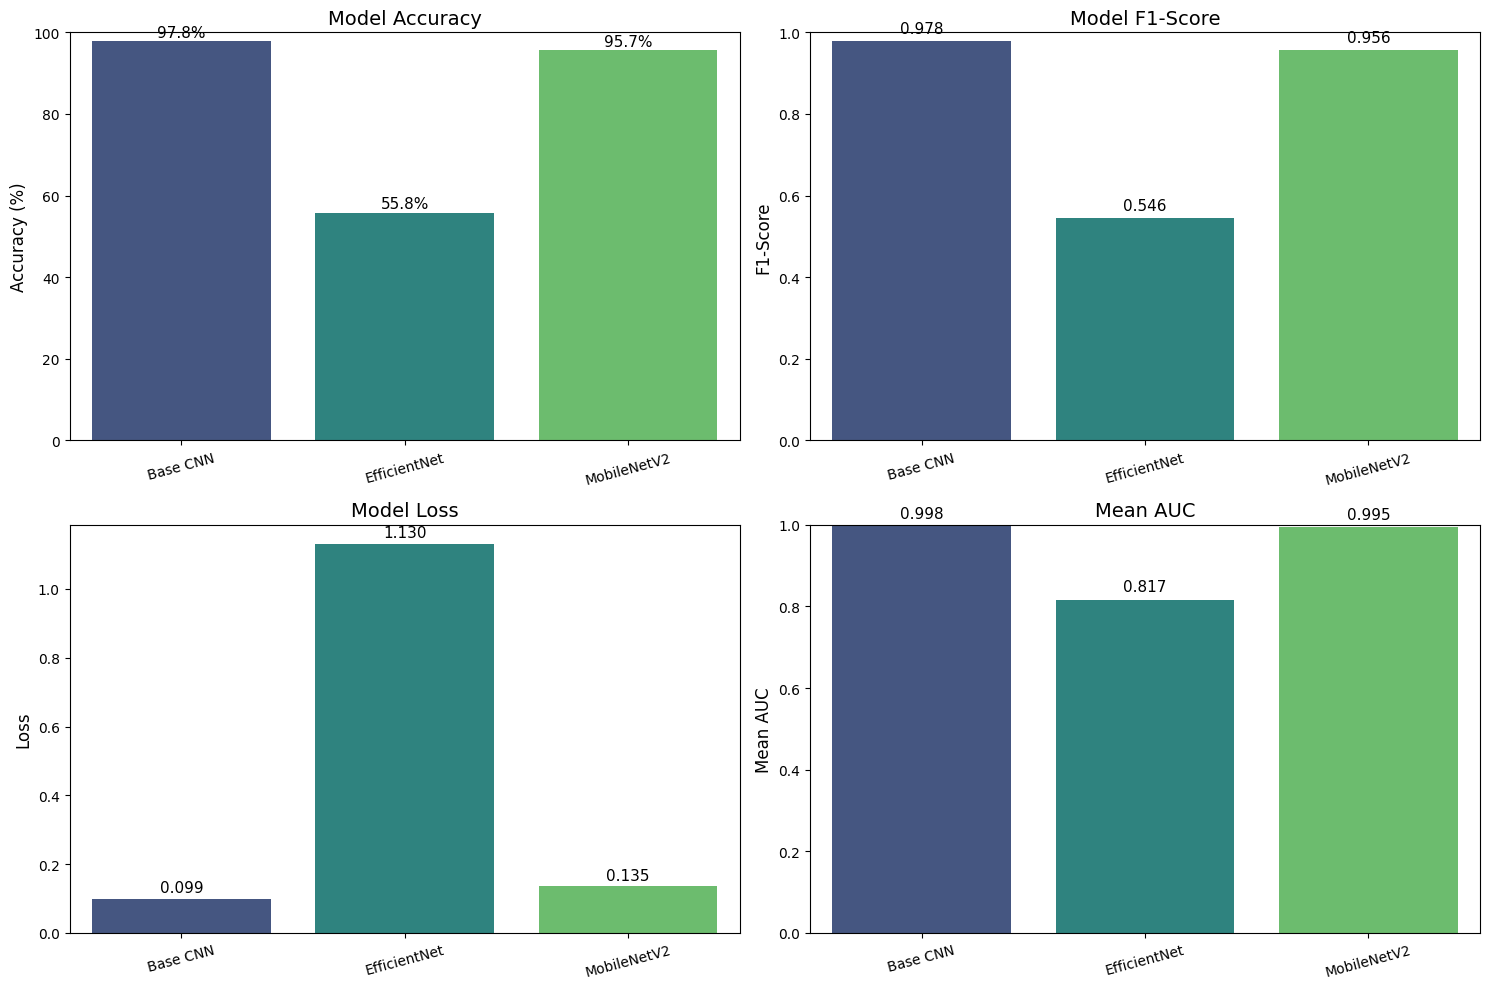

In [59]:
# Visualize key metrics
plt.figure(figsize=(15, 10))

# Accuracy
plt.subplot(2, 2, 1)
ax = sns.barplot(x='Model', y='Accuracy', data=metrics_df, palette='viridis')
plt.title('Model Accuracy', fontsize=14)
plt.xlabel('')
plt.ylabel('Accuracy (%)', fontsize=12)
plt.ylim(0, 100)
plt.xticks(rotation=15)
# Add values on bars
for i, v in enumerate(metrics_df['Accuracy']):
    ax.text(i, v + 1, f"{v:.1f}%", ha='center', fontsize=11)

# F1-Score
plt.subplot(2, 2, 2)
ax = sns.barplot(x='Model', y='F1-Score', data=metrics_df, palette='viridis')
plt.title('Model F1-Score', fontsize=14)
plt.xlabel('')
plt.ylabel('F1-Score', fontsize=12)
plt.ylim(0, 1)
plt.xticks(rotation=15)
# Add values on bars
for i, v in enumerate(metrics_df['F1-Score']):
    ax.text(i, v + 0.02, f"{v:.3f}", ha='center', fontsize=11)

# Loss
plt.subplot(2, 2, 3)
ax = sns.barplot(x='Model', y='Loss', data=metrics_df, palette='viridis')
plt.title('Model Loss', fontsize=14)
plt.xlabel('')
plt.ylabel('Loss', fontsize=12)
plt.xticks(rotation=15)
# Add values on bars
for i, v in enumerate(metrics_df['Loss']):
    ax.text(i, v + 0.02, f"{v:.3f}", ha='center', fontsize=11)

# Mean AUC
plt.subplot(2, 2, 4)
ax = sns.barplot(x='Model', y='Mean AUC', data=metrics_df, palette='viridis')
plt.title('Mean AUC', fontsize=14)
plt.xlabel('')
plt.ylabel('Mean AUC', fontsize=12)
plt.ylim(0, 1)
plt.xticks(rotation=15)
# Add values on bars
for i, v in enumerate(metrics_df['Mean AUC']):
    ax.text(i, v + 0.02, f"{v:.3f}", ha='center', fontsize=11)

plt.tight_layout()
plt.savefig(os.path.join(comparison_dir, 'metrics_comparison.png'), dpi=300)
plt.show()

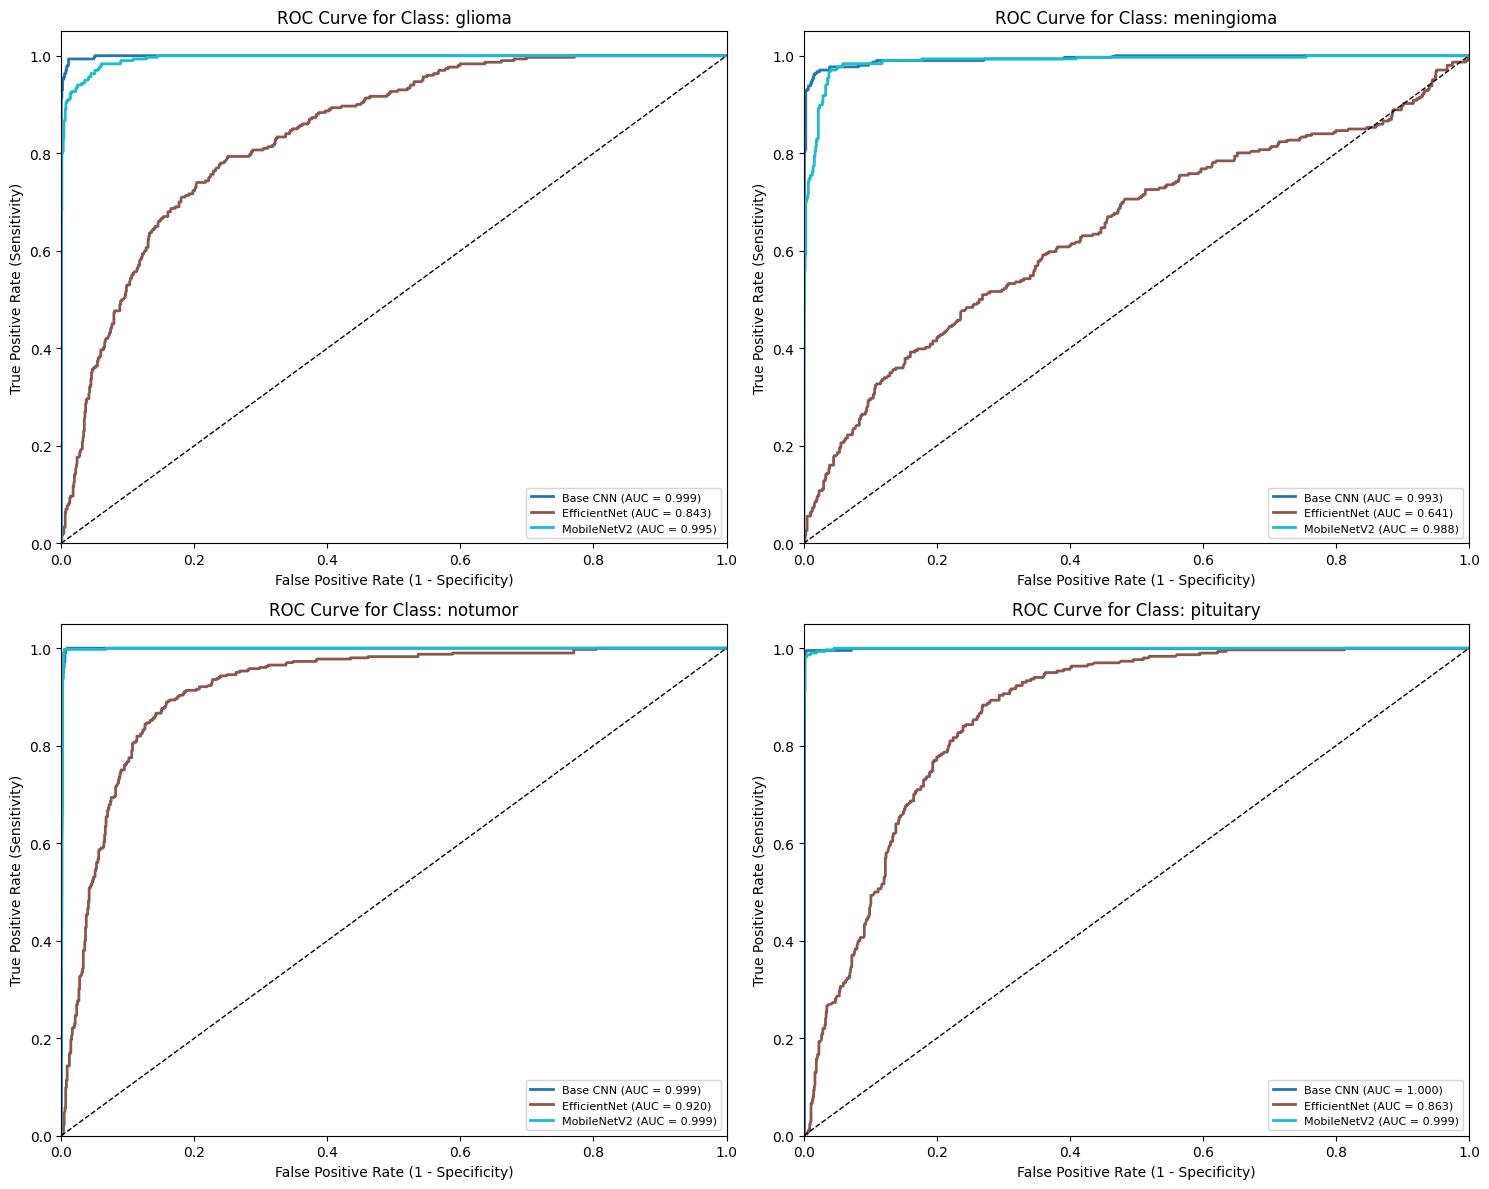

In [60]:
# ROC curves for each class
y_true_classes = np.argmax(y_test, axis=1)

plt.figure(figsize=(15, 12))
colors = plt.cm.tab10(np.linspace(0, 1, len(models_info)))

for c, cls in enumerate(classes):
    plt.subplot(2, 2, c+1)

    for m, (model_name, color) in enumerate(zip(predictions.keys(), colors)):
        y_pred = predictions[model_name]['y_pred']

        # Calculate ROC for this class
        fpr, tpr, _ = roc_curve(y_test[:, c], y_pred[:, c])
        roc_auc = auc(fpr, tpr)

        # Plot the curve
        plt.plot(fpr, tpr, color=color, lw=2,
               label=f"{model_name} (AUC = {roc_auc:.3f})")

    # Reference diagonal line
    plt.plot([0, 1], [0, 1], 'k--', lw=1)

    plt.xlim([0.0, 1.0])
    plt.ylim([0.0, 1.05])
    plt.xlabel('False Positive Rate (1 - Specificity)', fontsize=10)
    plt.ylabel('True Positive Rate (Sensitivity)', fontsize=10)
    plt.title(f'ROC Curve for Class: {cls}', fontsize=12)
    plt.legend(loc="lower right", fontsize=8)

plt.tight_layout()
plt.savefig(os.path.join(comparison_dir, 'roc_curves_by_class.png'), dpi=300)
plt.show()

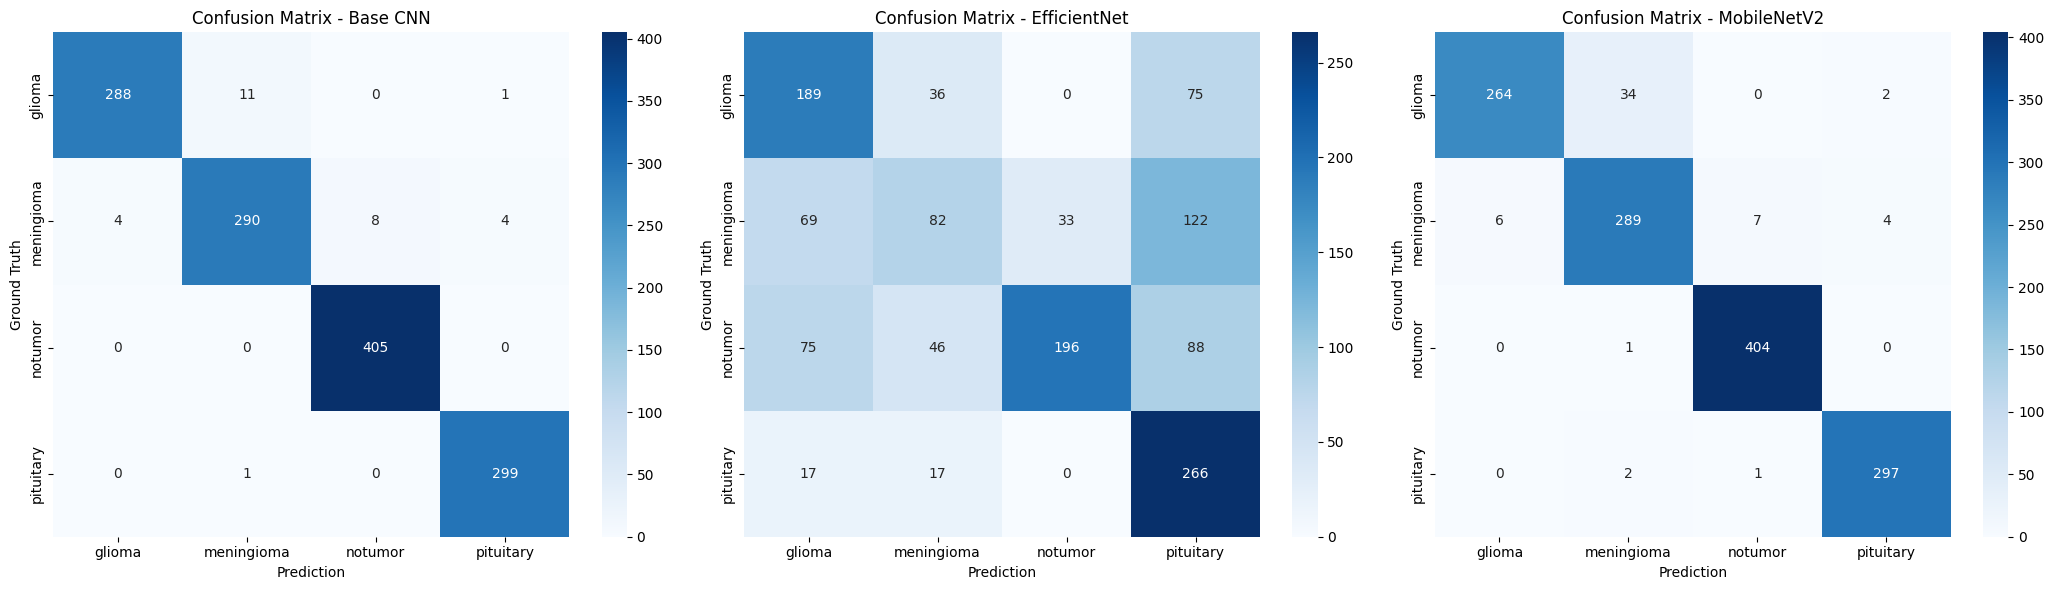

In [61]:
# Confusion matrices for each model
n_models = len(cm_dict)
fig, axes = plt.subplots(1, n_models, figsize=(7*n_models, 6))

if n_models == 1:  # Handle case with only one model
    axes = [axes]

for i, (model_name, cm) in enumerate(cm_dict.items()):
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
               xticklabels=classes, yticklabels=classes, ax=axes[i])
    axes[i].set_xlabel('Prediction')
    axes[i].set_ylabel('Ground Truth')
    axes[i].set_title(f'Confusion Matrix - {model_name}')

plt.tight_layout()
plt.savefig(os.path.join(comparison_dir, 'confusion_matrices.png'), dpi=300)
plt.show()

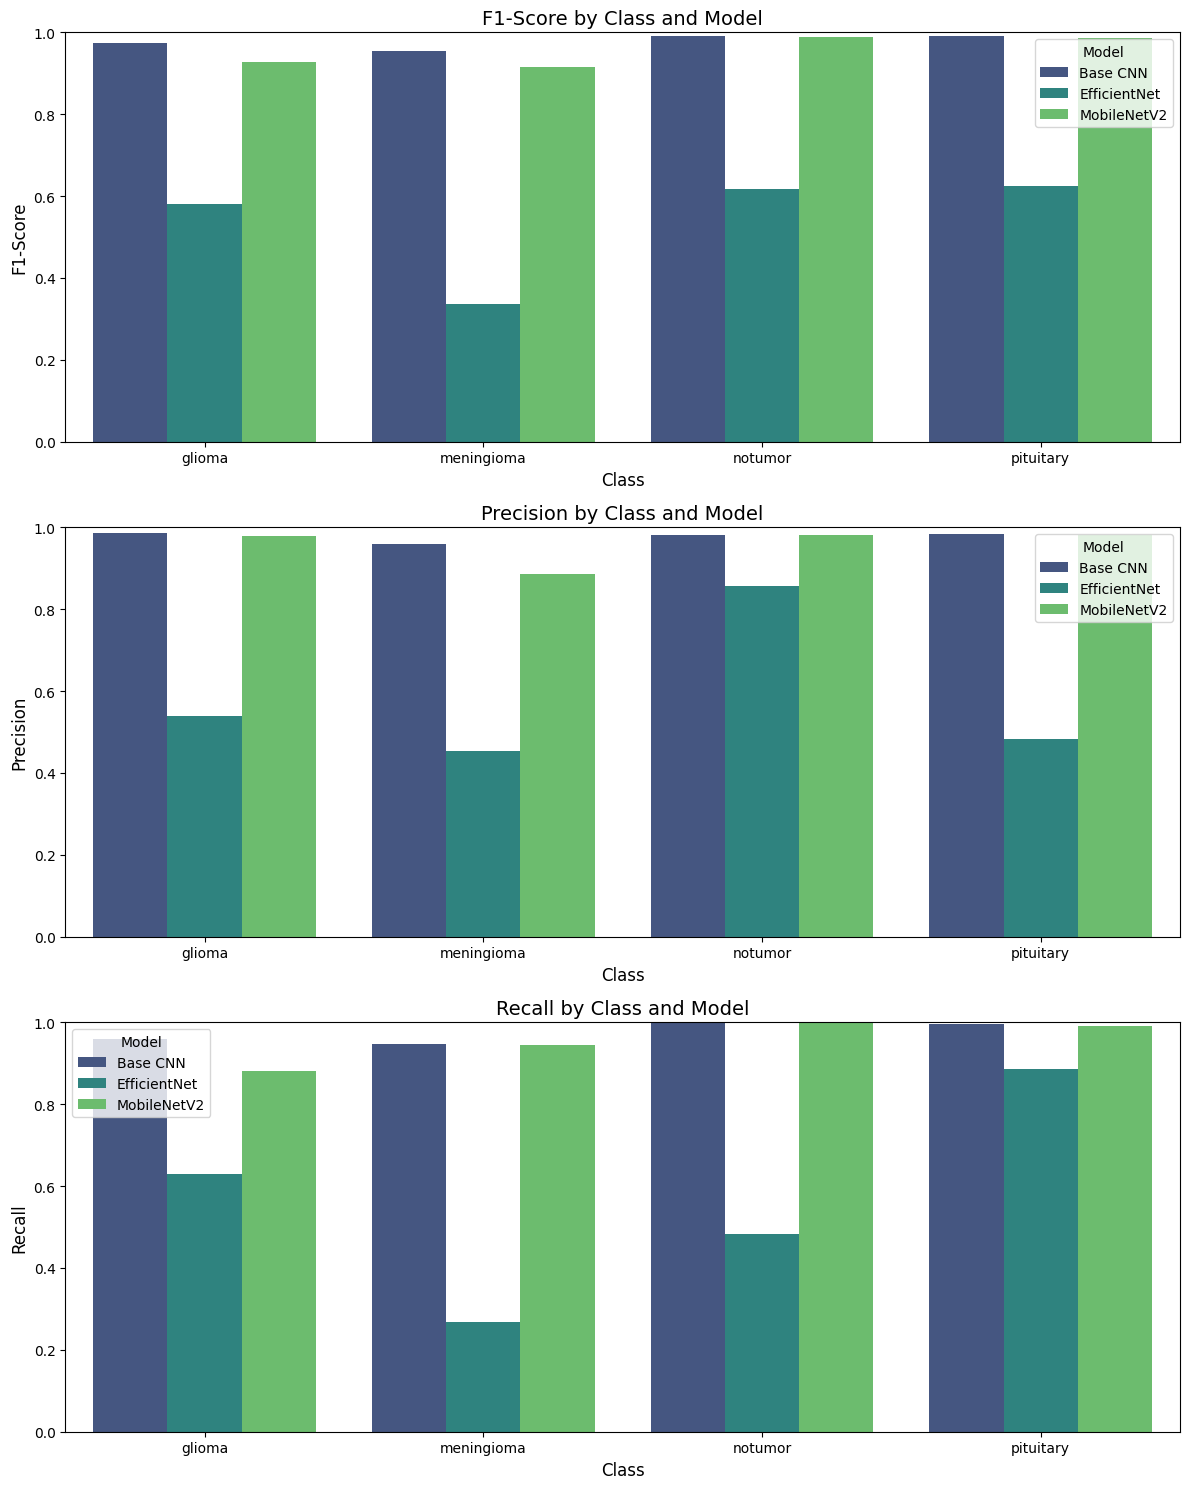

In [62]:
# Per-class performance for each model
performance_by_class = []

for model_name, pred_data in predictions.items():
    y_pred_classes = pred_data['y_pred_classes']

    report = classification_report(y_true_classes, y_pred_classes,
                                  target_names=classes, output_dict=True)

    for cls in classes:
        performance_by_class.append({
            'Model': model_name,
            'Class': cls,
            'F1-Score': report[cls]['f1-score'],
            'Precision': report[cls]['precision'],
            'Recall': report[cls]['recall'],
            'Support': report[cls]['support']
        })

performance_df = pd.DataFrame(performance_by_class)

# Compare metrics by class
metrics_to_plot = ['F1-Score', 'Precision', 'Recall']
fig, axes = plt.subplots(len(metrics_to_plot), 1, figsize=(12, 5*len(metrics_to_plot)))

for i, metric in enumerate(metrics_to_plot):
    sns.barplot(x='Class', y=metric, hue='Model', data=performance_df, ax=axes[i], palette='viridis')
    axes[i].set_title(f'{metric} by Class and Model', fontsize=14)
    axes[i].set_xlabel('Class', fontsize=12)
    axes[i].set_ylabel(metric, fontsize=12)
    axes[i].set_ylim(0, 1)
    axes[i].legend(title='Model')

plt.tight_layout()
plt.savefig(os.path.join(comparison_dir, 'metrics_by_class.png'), dpi=300)
plt.show()

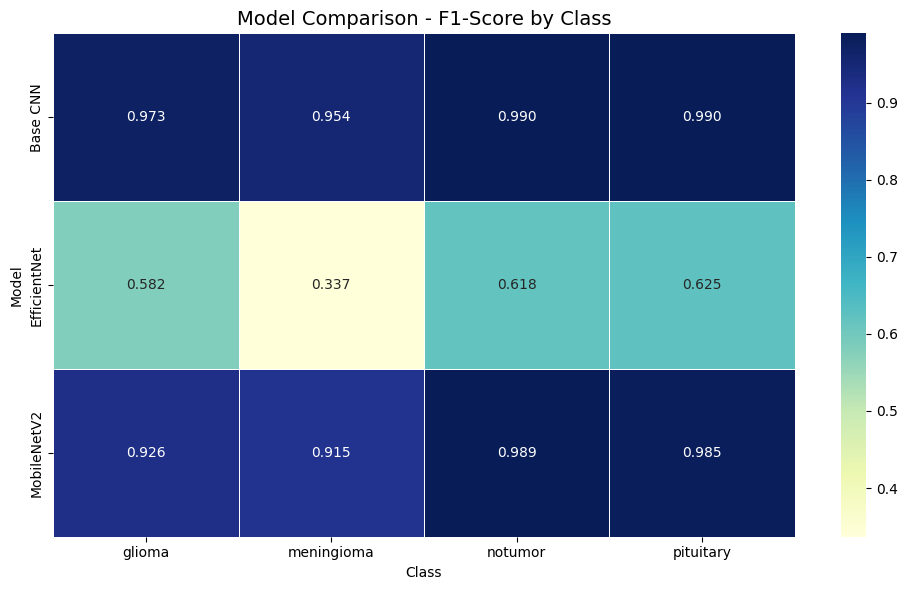

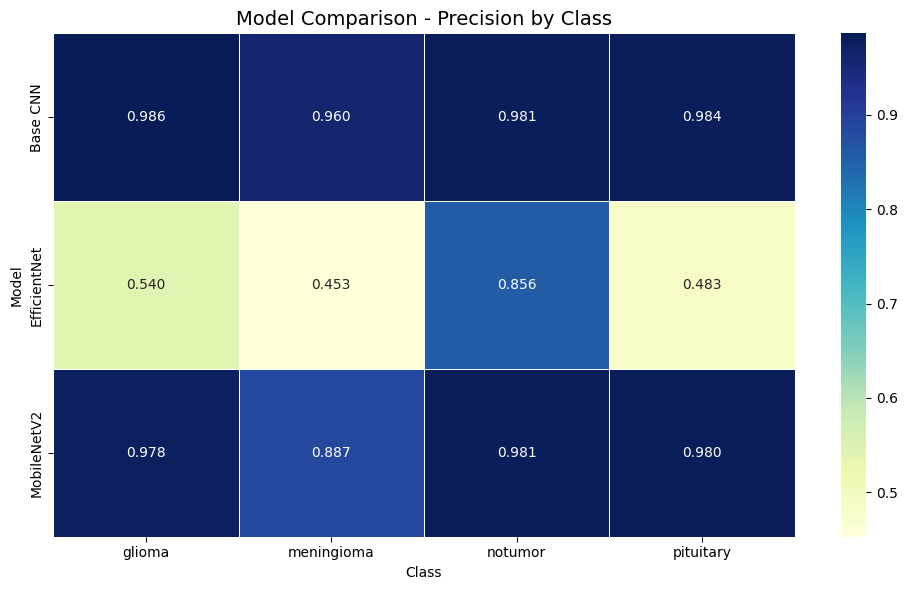

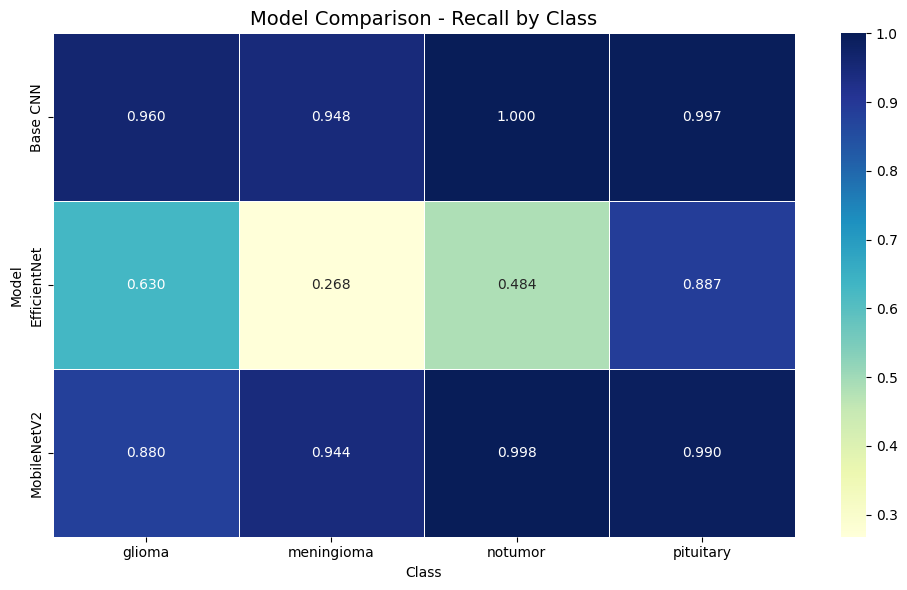

In [63]:
# Comparison matrix of models by class
for metric in metrics_to_plot:
    # Create pivot table for this metric
    pivot_table = performance_df.pivot_table(index='Model', columns='Class', values=metric)

    plt.figure(figsize=(10, 6))
    sns.heatmap(pivot_table, annot=True, cmap='YlGnBu', fmt='.3f', linewidths=.5)
    plt.title(f'Model Comparison - {metric} by Class', fontsize=14)
    plt.tight_layout()
    plt.savefig(os.path.join(comparison_dir, f'heatmap_{metric.lower().replace("-", "_")}.png'), dpi=300)
    plt.show()

In [64]:
# Save best model in keras format
best_model_name = metrics_df.sort_values('Accuracy', ascending=False).iloc[0]['Model']
print(f"\nBest model by accuracy: {best_model_name}")

for info in models_info:
    if info['name'] == best_model_name:
        best_model_path = os.path.join(info['dir'], info['file'])
        best_model = load_model(best_model_path)

        # Save in keras format for deployment
        deployment_path = os.path.join(comparison_dir, 'best_model_for_deployment.keras')
        best_model.save(deployment_path)
        print(f"Best model saved for deployment at: {deployment_path}")
        break

print(f"\nComparison results saved in: {comparison_dir}")
print("Comparative analysis completed!")


Best model by accuracy: Base CNN
Best model saved for deployment at: ./BrainTumorClassification\models\comparison\best_model_for_deployment.keras

Comparison results saved in: ./BrainTumorClassification\models\comparison
Comparative analysis completed!


## 8. Conclusions
Summary of the project and results

In [65]:
# Get best model performance
best_model_row = metrics_df.loc[metrics_df['Accuracy'].idxmax()]
best_model_name = best_model_row['Model']
best_accuracy = best_model_row['Accuracy']
best_f1 = best_model_row['F1-Score']

print("Project Summary")
print("=" * 50)
print("Brain Tumor MRI Classification Pipeline")
print("Dataset: Brain Tumor MRI Dataset (Kaggle)")
print(f"Classes: {', '.join(classes)}")
print(f"Training samples: {len(X_train)} (augmented from {len(X_train) // 4} original samples)")
print(f"Validation samples: {len(X_val)}")
print(f"Test samples: {len(X_test)}")
print("\nModels trained:")
for model in metrics_df['Model']:
    print(f"- {model}")
print("\nBest performing model:")
print(f"- Model: {best_model_name}")
print(f"- Accuracy: {best_accuracy:.2f}%")
print(f"- F1-Score: {best_f1:.4f}")
print("\nAll models have been saved in keras format for deployment.")
print(f"The best model is available at: {comparison_dir}/best_model_for_deployment.keras")
print("\nProject completed successfully!")

Project Summary
Brain Tumor MRI Classification Pipeline
Dataset: Brain Tumor MRI Dataset (Kaggle)
Classes: glioma, meningioma, notumor, pituitary
Training samples: 18276 (augmented from 4569 original samples)
Validation samples: 1143
Test samples: 1311

Models trained:
- Base CNN
- EfficientNet
- MobileNetV2

Best performing model:
- Model: Base CNN
- Accuracy: 97.79%
- F1-Score: 0.9778

All models have been saved in keras format for deployment.
The best model is available at: ./BrainTumorClassification\models\comparison/best_model_for_deployment.keras

Project completed successfully!
